experiment 4 - fine grid

this experiment follows on from the coarse grid experiment. The aim was to refine the results of looking into blocked feature selection and a coarse grid of hyperparameters by using more careful, feature by feature compositions of feature sets, and a hyperparameter grid that was more informed by the previous results.

As such, the design of the experiment and shape of the results is very similar to the previous experiment. I have simply copied the first few code cells from that notebook and changed the target directory to the new experiment in the hope it will all run perfectly once the results exist. (minor debugging is expected)



In [1]:
import json

import polars as pl
from project_paths import paths

experiment_dir = paths.experiments / "fine_grid"

results_file = experiment_dir / "runs.jsonl"

with open(results_file) as f:
    lines = [line for line in f]
    results = json.loads(lines[-1])

results 

{'run_id': 'a569ff2d-43cb-4b86-a746-f97c08214ccf',
 'run_at': '2026-08-11 19:08:18',
 'name': 'fine_grid',
 'smoke': False,
 'git_sha': '2349839d08541def87ada69c840462c0c813ffc2',
 'seed': 123,
 'n_blocks': 50,
 'n_splits': 10,
 'n_assets': 23304,
 'n_workers': 12,
 'omp_num_threads': 1,
 'n_configs': 630,
 'n_cells_total': 8823,
 'n_cells_run': 8823,
 'n_cells_skipped': 0,
 'grid': {'capacity': [0.4, 0.8, 1.6, 2.5, 5.0],
  'learning_rate': [0.025, 0.05, 0.1],
  'leaf_depth': [[2, None],
   [4, None],
   [4, 2],
   [8, None],
   [8, 3],
   [16, None],
   [16, 4]],
  'l2_regularization': [0.0, 1.0],
  'min_samples_leaf': [1, 5, 20]},
 'fixed_params': {'max_features': 1.0,
  'max_bins': 255,
  'early_stopping': False,
  'class_weight': None,
  'random_state': 123},
 'reference_config': {'capacity': 2.5,
  'learning_rate': 0.1,
  'max_leaf_nodes': 8,
  'max_depth': None,
  'l2_regularization': 0.0,
  'min_samples_leaf': 20},
 'compositions': {'identity': ['aims__asset_sub_type',
   'aims_

In [2]:

folds = pl.read_parquet(experiment_dir/"folds.parquet")
folds

asset_id,block_id,fold_id
i64,i16,i8
100006,20,3
100010,20,3
100015,14,3
100016,14,3
100017,14,3
…,…,…
99960,44,9
99963,36,1
99966,31,6


In [3]:
from typing import Iterable

oof_dir = experiment_dir / "oof"
oof_files = oof_dir.glob("*.parquet")

# loads in memory, switching to lazy evaluation and generator

frames: Iterable[pl.DataFrame] = (pl.read_parquet(file) for file in oof_files)

# frames[0]

In [4]:
# frm = frames[0].group_by("fold_id")

# print([_ for _ in frm])

In [5]:
# this takes about 25 mins with the extra frames

import numpy as np

from src.cross_validate import GRADES, Predictions
from src.metrics import build_scorers


fold_metrics_path = experiment_dir / "fold_metrics.parquet"
if fold_metrics_path.exists():
    fold_metrics = pl.read_parquet(fold_metrics_path)
else:
    

    proba_cols = [f"proba_{grade}" for grade in GRADES]
    scorers = build_scorers()

    # print(len(frames))

    fold_stats = []

    for frame in frames:
        # print(len(frame))
        for fold, data in frame.group_by("fold_id"):
            # print(fold)
            # print(data)

            fold_id = fold[0]
            y_values = data.get_column("y_true").to_numpy()

            prediction = Predictions(
                label=data.get_column("y_pred_argmax").to_numpy(),
                proba=data.select(proba_cols).to_numpy(),
                classes=np.asarray(GRADES),
            ) 

            fold_results = {
                "cell_id": data.get_column("cell_id").unique().item(),
                "fold_id": int(fold_id),
                "n": data.height,
                "n_ge4": int((y_values >= 4).sum()),
                **{name: float(fn(y_values, prediction)) for name, fn in scorers.items()},
            }

            fold_stats.append(fold_results)

    # fold_stats


    fold_metrics = pl.DataFrame(fold_stats).sort("cell_id", "fold_id")

    fold_metrics.write_parquet(fold_metrics_path)

fold_metrics.head()


cell_id,fold_id,n,n_ge4,mae,macro_f1,qwk,pr_auc_ge4,recall_for_grade_1,recall_for_grade_2,recall_for_grade_3,recall_for_grade_4,recall_for_grade_5,precision_for_grade_1,precision_for_grade_2,precision_for_grade_3,precision_for_grade_4,precision_for_grade_5,f1_for_grade_1,f1_for_grade_2,f1_for_grade_3,f1_for_grade_4,f1_for_grade_5
str,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""0011e9852415""",0,2174,263,0.381325,0.264306,0.259815,0.198938,0.131579,0.214408,0.969767,0.0,0.0,1.0,0.661376,0.631818,0.0,0.0,0.232558,0.323834,0.765138,0.0,0.0
"""0011e9852415""",1,2201,188,0.424353,0.20502,0.142156,0.169712,0.021277,0.153736,0.958268,0.0,0.0,0.5,0.59116,0.603072,0.0,0.0,0.040816,0.244014,0.740268,0.0,0.0
"""0011e9852415""",2,2486,215,0.320595,0.225241,0.200671,0.241335,0.0,0.203571,0.973022,0.0,0.0,0.0,0.655172,0.70199,0.0,0.0,0.0,0.310627,0.815578,0.0,0.0
"""0011e9852415""",3,2601,216,0.337947,0.222853,0.228687,0.109894,0.0,0.20384,0.977751,0.0,0.0,0.0,0.676471,0.678348,0.0,0.0,0.0,0.31328,0.800985,0.0,0.0
"""0011e9852415""",4,2294,182,0.37184,0.204925,0.238301,0.143102,0.0,0.1578125,0.971045,0.0,0.0,0.0,0.531579,0.653517,0.0,0.0,0.0,0.243373,0.78125,0.0,0.0


In [6]:
id_cols = ["cell_id", "fold_id", "n", "n_ge4"]
long = fold_metrics.unpivot(
    index=id_cols,
    on=[c for c in fold_metrics.columns if c not in id_cols],
    variable_name="metric",
    value_name="value",
)

long.head()

cell_id,fold_id,n,n_ge4,metric,value
str,i64,i64,i64,str,f64
"""0011e9852415""",0,2174,263,"""mae""",0.381325
"""0011e9852415""",1,2201,188,"""mae""",0.424353
"""0011e9852415""",2,2486,215,"""mae""",0.320595
"""0011e9852415""",3,2601,216,"""mae""",0.337947
"""0011e9852415""",4,2294,182,"""mae""",0.37184


In [7]:
# cells = [json.loads(line) for line in lines if json.loads(line)["kind"] == "cell"]

# grid_axes = ["max_iter", "max_leaf_nodes", "min_samples_leaf", "l2_regularization", "max_features"]

# cell_meta = pl.DataFrame(
#     [
#         {
#             "cell_id": cell["cell_id"],
#             "model": cell["model"],
#             "feature_set": cell["feature_set"],
#             "seconds": cell["seconds"],
#             "wants_full_shap": cell["wants_full_shap"],
#             **{axis: cell["params"].get(axis) for axis in grid_axes},
#         }
#         for cell in cells
#     ]
# ).with_columns(
#     pl.when(pl.col("feature_set").is_null())
#     .then(None)
#     .otherwise(pl.concat_str([pl.col(a).cast(pl.Utf8) for a in grid_axes], separator="|"))
#     .alias("config_key")
# )

# fold_metrics = fold_metrics.join(cell_meta, on="cell_id", how="left", validate="m:1")

# fold_metrics


import json

meta_dir = experiment_dir / "meta"

GRID_AXES = [
    "learning_rate",
    "max_iter",
    "max_leaf_nodes",
    "max_depth",
    "l2_regularization",
    "min_samples_leaf",
]

records = [json.loads(p.read_text()) for p in sorted(meta_dir.glob("*.json"))]

cell_meta = pl.DataFrame(
    [
        {
            "cell_id": r["cell_id"],
            "model": r["model"],
            "composition": r["composition"],
            "capacity": r.get("capacity"),
            "wants_full_shap": r["wants_full_shap"],
            "seconds_fit": r.get("seconds_fit"),
            "seconds_shap": r.get("seconds_shap"),
            "seconds_total": r.get("seconds_total"),
            **{axis: r["params"].get(axis) for axis in GRID_AXES},
        }
        for r in records
    ],
    infer_schema_length=None,
).with_columns(
    pl.when(pl.col("composition").is_null())
    .then(None)
    .otherwise(
        pl.concat_str(
            [pl.col(a).cast(pl.Utf8).fill_null("none") for a in GRID_AXES],
            separator="|",
        )
    )
    .alias("config_key")
)

assert cell_meta.height == results["n_cells_total"], (
    f"{cell_meta.height} meta files vs {results['n_cells_total']} expected"
)
assert cell_meta.filter(pl.col("model") == "hgb").get_column("config_key").null_count() == 0
assert cell_meta.filter(pl.col("model") == "hgb").get_column("config_key").n_unique() == 630

fold_metrics = fold_metrics.join(cell_meta, on="cell_id", how="left", validate="m:1")
fold_metrics.head()

cell_id,fold_id,n,n_ge4,mae,macro_f1,qwk,pr_auc_ge4,recall_for_grade_1,recall_for_grade_2,recall_for_grade_3,recall_for_grade_4,recall_for_grade_5,precision_for_grade_1,precision_for_grade_2,precision_for_grade_3,precision_for_grade_4,precision_for_grade_5,f1_for_grade_1,f1_for_grade_2,f1_for_grade_3,f1_for_grade_4,f1_for_grade_5,model,composition,capacity,wants_full_shap,seconds_fit,seconds_shap,seconds_total,learning_rate,max_iter,max_leaf_nodes,max_depth,l2_regularization,min_samples_leaf,config_key
str,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,str,f64,bool,f64,f64,f64,f64,i64,i64,i64,f64,i64,str
"""0011e9852415""",0,2174,263,0.381325,0.264306,0.259815,0.198938,0.131579,0.214408,0.969767,0.0,0.0,1.0,0.661376,0.631818,0.0,0.0,0.232558,0.323834,0.765138,0.0,0.0,"""hgb""","""identity_climate_full""",0.8,false,1.601,0.189,2.098,0.05,16,4,2,0.0,1,"""0.05|16|4|2|0.0|1"""
"""0011e9852415""",1,2201,188,0.424353,0.20502,0.142156,0.169712,0.021277,0.153736,0.958268,0.0,0.0,0.5,0.59116,0.603072,0.0,0.0,0.040816,0.244014,0.740268,0.0,0.0,"""hgb""","""identity_climate_full""",0.8,false,1.601,0.189,2.098,0.05,16,4,2,0.0,1,"""0.05|16|4|2|0.0|1"""
"""0011e9852415""",2,2486,215,0.320595,0.225241,0.200671,0.241335,0.0,0.203571,0.973022,0.0,0.0,0.0,0.655172,0.70199,0.0,0.0,0.0,0.310627,0.815578,0.0,0.0,"""hgb""","""identity_climate_full""",0.8,false,1.601,0.189,2.098,0.05,16,4,2,0.0,1,"""0.05|16|4|2|0.0|1"""
"""0011e9852415""",3,2601,216,0.337947,0.222853,0.228687,0.109894,0.0,0.20384,0.977751,0.0,0.0,0.0,0.676471,0.678348,0.0,0.0,0.0,0.31328,0.800985,0.0,0.0,"""hgb""","""identity_climate_full""",0.8,false,1.601,0.189,2.098,0.05,16,4,2,0.0,1,"""0.05|16|4|2|0.0|1"""
"""0011e9852415""",4,2294,182,0.37184,0.204925,0.238301,0.143102,0.0,0.1578125,0.971045,0.0,0.0,0.0,0.531579,0.653517,0.0,0.0,0.0,0.243373,0.78125,0.0,0.0,"""hgb""","""identity_climate_full""",0.8,false,1.601,0.189,2.098,0.05,16,4,2,0.0,1,"""0.05|16|4|2|0.0|1"""


In [22]:
# with pl.Config(tbl_rows=-1, tbl_cols=-1, tbl_width_chars=400):
#     print(fold_metrics)

In [9]:
cell_metrics_cv =  (
    long.group_by("cell_id", "metric")
    .agg(
        pl.col("value").filter(pl.col("value").is_not_nan()).mean().alias("mean"),
        pl.col("value").filter(pl.col("value").is_not_nan()).std().alias("std"),
        pl.col("value").is_nan().sum().alias("n_nan"),
        pl.len().alias("n_folds"),
    )
    .join(cell_meta, on="cell_id", how="left", validate="m:1")
    .sort("metric", "mean", descending=[False, True])
)

cell_metrics_cv.head()

cell_id,metric,mean,std,n_nan,n_folds,model,composition,capacity,wants_full_shap,seconds_fit,seconds_shap,seconds_total,learning_rate,max_iter,max_leaf_nodes,max_depth,l2_regularization,min_samples_leaf,config_key
str,str,f64,f64,u32,u32,str,str,f64,bool,f64,f64,f64,f64,i64,i64,i64,f64,i64,str
"""ae575555d491""","""f1_for_grade_1""",0.290643,0.254809,0,10,"""hgb""","""identity""",2.5,false,2.352,0.61,3.47,0.1,25,8,3,0.0,1,"""0.1|25|8|3|0.0|1"""
"""1ee29803f9e1""","""f1_for_grade_1""",0.288389,0.253153,0,10,"""hgb""","""identity_lidar_climate_z""",1.6,false,2.004,0.398,2.776,0.1,16,8,3,0.0,5,"""0.1|16|8|3|0.0|5"""
"""8b6b8f7559d8""","""f1_for_grade_1""",0.28632,0.25708,0,10,"""hgb""","""identity""",1.6,false,1.324,0.34,2.012,0.1,16,8,null,0.0,5,"""0.1|16|8|none|0.0|5"""
"""0b092b1a9e32""","""f1_for_grade_1""",0.28421,0.253267,0,10,"""hgb""","""identity""",2.5,false,2.679,0.712,4.019,0.1,25,8,3,0.0,5,"""0.1|25|8|3|0.0|5"""
"""880c271aea1c""","""f1_for_grade_1""",0.284083,0.25617,0,10,"""hgb""","""identity_climate_z""",1.6,false,1.714,0.403,2.488,0.1,16,8,3,0.0,5,"""0.1|16|8|3|0.0|5"""


In [10]:
cell_summary = (
    cell_metrics_cv.pivot(on="metric", index="cell_id", values="mean")
    .join(cell_meta, on="cell_id", how="left", validate="1:1")
    .sort("composition", "pr_auc_ge4", descending=[False, True])
)

cell_summary

cell_id,f1_for_grade_1,f1_for_grade_2,f1_for_grade_3,f1_for_grade_4,f1_for_grade_5,macro_f1,mae,pr_auc_ge4,precision_for_grade_1,precision_for_grade_2,precision_for_grade_3,precision_for_grade_4,precision_for_grade_5,qwk,recall_for_grade_1,recall_for_grade_2,recall_for_grade_3,recall_for_grade_4,recall_for_grade_5,model,composition,capacity,wants_full_shap,seconds_fit,seconds_shap,seconds_total,learning_rate,max_iter,max_leaf_nodes,max_depth,l2_regularization,min_samples_leaf,config_key
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,str,f64,bool,f64,f64,f64,f64,i64,i64,i64,f64,i64,str
"""ba81faf7a77c""",0.154872,0.259339,0.605702,0.058673,0.025921,0.220901,0.794041,0.098838,0.092383,0.369976,0.653088,0.066111,0.015269,0.185143,0.537633,0.208785,0.576927,0.066264,0.124264,"""heuristic_national""",null,null,false,0.0,0.0,0.064,null,null,null,null,null,null,null
"""0c7581b6dc44""",0.013038,0.274346,0.612037,0.086004,0.0,0.197085,0.641249,0.097513,0.014421,0.275233,0.609304,0.089209,0.0,-0.000851,0.012114,0.275723,0.616531,0.084127,0.0,"""dummy_stratified""",null,null,false,0.013,0.0,0.11,null,null,null,null,null,null,null
"""4afa0082a12f""",0.0,0.0,0.756443,0.0,0.0,0.151289,0.421228,0.096583,0.0,0.0,0.609269,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,"""dummy_median""",null,null,false,0.013,0.0,0.088,null,null,null,null,null,null,null
"""da2ed2fa075c""",0.21026,0.370384,0.769366,0.0,0.0,0.270002,0.377277,0.178136,0.348799,0.565749,0.658463,0.0,0.0,0.282329,0.160011,0.279169,0.92728,0.0,0.0,"""hgb""","""identity""",1.6,false,1.379,0.334,2.058,0.1,16,8,null,0.0,20,"""0.1|16|8|none|0.0|20"""
"""3ee966313c50""",0.254924,0.398827,0.768136,0.0,0.0,0.284378,0.375767,0.177637,0.373537,0.567793,0.663664,0.0,0.0,0.304086,0.212496,0.313419,0.913923,0.0,0.0,"""hgb""","""identity""",5.0,false,3.925,0.694,5.539,0.1,50,4,2,0.0,1,"""0.1|50|4|2|0.0|1"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""708db9898399""",0.0,0.0,0.756443,0.0,0.0,0.151289,0.421228,0.158793,0.0,0.0,0.609269,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,"""hgb""","""identity_resid_std""",0.4,false,0.349,0.034,0.505,0.1,4,2,null,1.0,1,"""0.1|4|2|none|1.0|1"""
"""f05592b3e6c8""",0.0,0.0,0.756443,0.0,0.0,0.151289,0.421228,0.158793,0.0,0.0,0.609269,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,"""hgb""","""identity_resid_std""",0.4,false,0.36,0.036,0.514,0.1,4,2,null,1.0,20,"""0.1|4|2|none|1.0|20"""
"""3a46210a09b6""",0.0,0.0,0.756443,0.0,0.0,0.151289,0.421228,0.158198,0.0,0.0,0.609269,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,"""hgb""","""identity_resid_std""",0.4,false,0.352,0.031,0.502,0.1,4,2,null,0.0,1,"""0.1|4|2|none|0.0|1"""


In [11]:
with pl.Config(tbl_rows=50, tbl_cols=-1, tbl_width_chars=400):
    print(cell_summary.sort(by="qwk", descending=True).head(50))


shape: (50, 34)
┌───────────┬───────────┬───────────┬───────────┬───────────┬───────────┬──────────┬──────────┬───────────┬───────────┬───────────┬───────────┬───────────┬───────────┬──────────┬───────────┬───────────┬───────────┬───────────┬───────────┬───────┬───────────┬──────────┬───────────┬───────────┬───────────┬───────────┬───────────┬──────────┬───────────┬───────────┬───────────┬───────────┬───────────┐
│ cell_id   ┆ f1_for_gr ┆ f1_for_gr ┆ f1_for_gr ┆ f1_for_gr ┆ f1_for_gr ┆ macro_f1 ┆ mae      ┆ pr_auc_ge ┆ precision ┆ precision ┆ precision ┆ precision ┆ precision ┆ qwk      ┆ recall_fo ┆ recall_fo ┆ recall_fo ┆ recall_fo ┆ recall_fo ┆ model ┆ compositi ┆ capacity ┆ wants_ful ┆ seconds_f ┆ seconds_s ┆ seconds_t ┆ learning_ ┆ max_iter ┆ max_leaf_ ┆ max_depth ┆ l2_regula ┆ min_sampl ┆ config_ke │
│ ---       ┆ ade_1     ┆ ade_2     ┆ ade_3     ┆ ade_4     ┆ ade_5     ┆ ---      ┆ ---      ┆ 4         ┆ _for_grad ┆ _for_grad ┆ _for_grad ┆ _for_grad ┆ _for_grad ┆ ---      ┆ r_g

In [12]:

with pl.Config(tbl_rows=-1):
    print(
        cell_metrics_cv.filter(pl.col("metric") == "pr_auc_ge4").group_by("composition").agg(
            pl.col("mean").max().alias("best"),
            pl.col("mean").median().alias("median"),
            pl.col("mean").min().alias("worst"),
        )
    )

shape: (15, 4)
┌────────────────────────────────┬──────────┬──────────┬──────────┐
│ composition                    ┆ best     ┆ median   ┆ worst    │
│ ---                            ┆ ---      ┆ ---      ┆ ---      │
│ str                            ┆ f64      ┆ f64      ┆ f64      │
╞════════════════════════════════╪══════════╪══════════╪══════════╡
│ identity_lidar_offset          ┆ 0.194752 ┆ 0.183993 ┆ 0.156466 │
│ identity_lidar_bedrock         ┆ 0.198683 ┆ 0.184649 ┆ 0.159072 │
│ identity_resid_std             ┆ 0.193384 ┆ 0.183739 ┆ 0.158198 │
│ identity_lidar_climate_bedrock ┆ 0.196412 ┆ 0.180568 ┆ 0.155966 │
│ identity_climate_z             ┆ 0.177119 ┆ 0.169973 ┆ 0.147984 │
│ identity_lidar_climate_z       ┆ 0.191712 ┆ 0.182342 ┆ 0.156342 │
│ identity_bedrock               ┆ 0.186799 ┆ 0.172641 ┆ 0.145064 │
│ identity_lidar_no_tv           ┆ 0.194305 ┆ 0.183737 ┆ 0.156466 │
│ identity_climate_full          ┆ 0.177119 ┆ 0.167542 ┆ 0.14124  │
│ identity_climate_raw           

In [13]:

with pl.Config(tbl_rows=-1):
    print(
        cell_metrics_cv.filter(pl.col("metric") == "qwk").group_by("composition").agg(
            pl.col("mean").max().alias("best"),
            pl.col("mean").median().alias("median"),
            pl.col("mean").min().alias("worst"),
        )
    )

shape: (15, 4)
┌────────────────────────────────┬──────────┬──────────┬───────────┐
│ composition                    ┆ best     ┆ median   ┆ worst     │
│ ---                            ┆ ---      ┆ ---      ┆ ---       │
│ str                            ┆ f64      ┆ f64      ┆ f64       │
╞════════════════════════════════╪══════════╪══════════╪═══════════╡
│ identity_climate_full          ┆ 0.299364 ┆ 0.258982 ┆ 0.0       │
│ identity_bedrock               ┆ 0.285797 ┆ 0.239015 ┆ 0.0       │
│ identity_climate_z             ┆ 0.302418 ┆ 0.269909 ┆ 0.0       │
│ identity_lidar_offset          ┆ 0.309223 ┆ 0.270132 ┆ 0.0       │
│ identity_lidar_no_tv           ┆ 0.307452 ┆ 0.269823 ┆ 0.0       │
│ identity_lidar_climate_bedrock ┆ 0.282696 ┆ 0.233393 ┆ 0.0       │
│ identity                       ┆ 0.307577 ┆ 0.270342 ┆ 0.0       │
│ identity_lidar_climate_z       ┆ 0.30542  ┆ 0.270066 ┆ 0.0       │
│ identity_resid_std             ┆ 0.306976 ┆ 0.269968 ┆ 0.0       │
│ identity_climate_

In [14]:
with pl.Config(tbl_rows=-1):
    print(

        cell_metrics_cv.filter(pl.col("metric") == "macro_f1").group_by("composition").agg(
            pl.col("mean").max().alias("best"),
            pl.col("mean").median().alias("median"),
            pl.col("mean").min().alias("worst"),
        )

    )

shape: (15, 4)
┌────────────────────────────────┬──────────┬──────────┬──────────┐
│ composition                    ┆ best     ┆ median   ┆ worst    │
│ ---                            ┆ ---      ┆ ---      ┆ ---      │
│ str                            ┆ f64      ┆ f64      ┆ f64      │
╞════════════════════════════════╪══════════╪══════════╪══════════╡
│ identity                       ┆ 0.289589 ┆ 0.257434 ┆ 0.151289 │
│ null                           ┆ 0.220901 ┆ 0.197085 ┆ 0.151289 │
│ identity_lidar_climate_raw     ┆ 0.280729 ┆ 0.250857 ┆ 0.151289 │
│ identity_resid_std             ┆ 0.290528 ┆ 0.258706 ┆ 0.151289 │
│ identity_climate_raw           ┆ 0.279648 ┆ 0.25041  ┆ 0.151279 │
│ identity_bedrock               ┆ 0.280341 ┆ 0.241269 ┆ 0.151289 │
│ identity_lidar_offset          ┆ 0.289698 ┆ 0.25832  ┆ 0.151289 │
│ identity_lidar_climate_z       ┆ 0.288536 ┆ 0.258364 ┆ 0.151289 │
│ identity_climate_full          ┆ 0.28279  ┆ 0.250771 ┆ 0.151249 │
│ identity_lidar_no_tv           

we now have cells where the model fails completely - qwk is colapsing to 0, and f1 hits a floor. So this means the hyperparameter grid now have cells, probably the max leafs =2, that aren't producing valid models. This is good from the point of view of the hyperparameter tuning. It means that the grid now spans a range of parameters that definitely contains the optimum, since performance metrics were still increasing into the section of the grid that was extended, and it now reaches a performance floor. 

but it means that the averages aren't directly usable. The medians will all be lower because they include the floor/zero stats. 

In [15]:
colapsed = (
    pl.DataFrame(
        [
            {
                "cell_id": frame.get_column("cell_id").first(),
                "n_pred_classes": frame.get_column("y_pred_argmax").n_unique(),
                "n_score_values": frame.select(
                    pl.sum_horizontal("proba_4", "proba_5").alias("s")
                ).get_column("s").n_unique(),
            }
            for frame in (
                pl.read_parquet(f) for f in sorted(oof_dir.glob("*.parquet"))
            )
        ]
    )
    .join(cell_meta, on="cell_id", how="left", validate="1:1")
    .with_columns(
        (pl.col("n_pred_classes") == 1).alias("argmax_degenerate"),
        (pl.col("n_score_values") < 100).alias("ranking_degenerate"),
    )
    .with_columns(
        (pl.col("argmax_degenerate") | pl.col("ranking_degenerate")).alias("is_degenerate")
    )
)

colapsed_configs = (
    colapsed.filter((pl.col("model") == "hgb") & pl.col("is_degenerate"))
    .get_column("config_key")
    .unique()
)

colapsed.filter(pl.col("model") == "hgb").group_by("capacity", "max_leaf_nodes").agg(
    pl.col("is_degenerate").mean().alias("share_degenerate"),
    pl.col("n_score_values").min().alias("min_scores"),
    pl.len(),
).sort("capacity", "max_leaf_nodes")

capacity,max_leaf_nodes,share_degenerate,min_scores,len
f64,i64,f64,i64,u32
0.4,2,1.0,890,252
0.4,4,0.180556,2122,504
0.4,8,0.0,4555,504
0.4,16,0.0,7515,504
0.8,2,0.0,2319,252
…,…,…,…,…
2.5,16,0.0,17109,504
5.0,2,0.0,13380,252
5.0,4,0.0,15731,504


In [17]:
fold_metrics_nd = fold_metrics.filter(
    pl.col("config_key").is_null() | ~pl.col("config_key").is_in(colapsed_configs.to_list())
)

long_nd = fold_metrics_nd.unpivot(
    index=id_cols,
    on=[c for c in fold_metrics.columns if c not in id_cols and c not in cell_meta.columns],
    variable_name="metric",
    value_name="value",
)

cell_metrics_cv_nd = (
    long_nd.group_by("cell_id", "metric")
    .agg(
        pl.col("value").filter(pl.col("value").is_not_nan()).mean().alias("mean"),
        pl.col("value").filter(pl.col("value").is_not_nan()).std().alias("std"),
        pl.col("value").is_nan().sum().alias("n_nan"),
        pl.len().alias("n_folds"),
    )
    .join(cell_meta, on="cell_id", how="left", validate="m:1")
    .sort("metric", "mean", descending=[False, True])
)

cell_summary_nd = (
    cell_metrics_cv_nd.pivot(on="metric", index="cell_id", values="mean")
    .join(cell_meta, on="cell_id", how="left", validate="1:1")
    .sort("composition", "pr_auc_ge4", descending=[False, True])
)

cell_summary_nd

cell_id,f1_for_grade_1,f1_for_grade_2,f1_for_grade_3,f1_for_grade_4,f1_for_grade_5,macro_f1,mae,pr_auc_ge4,precision_for_grade_1,precision_for_grade_2,precision_for_grade_3,precision_for_grade_4,precision_for_grade_5,qwk,recall_for_grade_1,recall_for_grade_2,recall_for_grade_3,recall_for_grade_4,recall_for_grade_5,model,composition,capacity,wants_full_shap,seconds_fit,seconds_shap,seconds_total,learning_rate,max_iter,max_leaf_nodes,max_depth,l2_regularization,min_samples_leaf,config_key
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,str,f64,bool,f64,f64,f64,f64,i64,i64,i64,f64,i64,str
"""ba81faf7a77c""",0.154872,0.259339,0.605702,0.058673,0.025921,0.220901,0.794041,0.098838,0.092383,0.369976,0.653088,0.066111,0.015269,0.185143,0.537633,0.208785,0.576927,0.066264,0.124264,"""heuristic_national""",null,null,false,0.0,0.0,0.064,null,null,null,null,null,null,null
"""0c7581b6dc44""",0.013038,0.274346,0.612037,0.086004,0.0,0.197085,0.641249,0.097513,0.014421,0.275233,0.609304,0.089209,0.0,-0.000851,0.012114,0.275723,0.616531,0.084127,0.0,"""dummy_stratified""",null,null,false,0.013,0.0,0.11,null,null,null,null,null,null,null
"""4afa0082a12f""",0.0,0.0,0.756443,0.0,0.0,0.151289,0.421228,0.096583,0.0,0.0,0.609269,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,"""dummy_median""",null,null,false,0.013,0.0,0.088,null,null,null,null,null,null,null
"""da2ed2fa075c""",0.21026,0.370384,0.769366,0.0,0.0,0.270002,0.377277,0.178136,0.348799,0.565749,0.658463,0.0,0.0,0.282329,0.160011,0.279169,0.92728,0.0,0.0,"""hgb""","""identity""",1.6,false,1.379,0.334,2.058,0.1,16,8,null,0.0,20,"""0.1|16|8|none|0.0|20"""
"""3ee966313c50""",0.254924,0.398827,0.768136,0.0,0.0,0.284378,0.375767,0.177637,0.373537,0.567793,0.663664,0.0,0.0,0.304086,0.212496,0.313419,0.913923,0.0,0.0,"""hgb""","""identity""",5.0,false,3.925,0.694,5.539,0.1,50,4,2,0.0,1,"""0.1|50|4|2|0.0|1"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""d881771ac84c""",0.077018,0.09612,0.761633,0.0,0.0,0.186954,0.406785,0.166251,0.3175,0.570739,0.620282,0.0,0.0,0.09205,0.050692,0.054392,0.98947,0.0,0.0,"""hgb""","""identity_resid_std""",0.8,false,0.507,0.052,0.706,0.1,8,2,null,0.0,5,"""0.1|8|2|none|0.0|5"""
"""d2c499e6dc48""",0.055744,0.015579,0.75711,0.0,0.0,0.165687,0.419033,0.166197,0.205556,0.092696,0.611316,0.0,0.0,0.025248,0.033276,0.008531,0.997079,0.0,0.0,"""hgb""","""identity_resid_std""",0.4,false,0.402,0.048,0.581,0.1,4,4,2,0.0,20,"""0.1|4|4|2|0.0|20"""
"""99b7ec1b900f""",0.0,0.09093,0.761559,0.0,0.0,0.170498,0.407616,0.165868,0.0,0.547483,0.619562,0.0,0.0,0.081214,0.0,0.051032,0.991054,0.0,0.0,"""hgb""","""identity_resid_std""",0.8,false,0.845,0.086,1.151,0.05,16,2,null,0.0,5,"""0.05|16|2|none|0.0|5"""


In [24]:

with pl.Config(tbl_rows=-1):
    print(
        cell_metrics_cv_nd.filter(pl.col("metric") == "pr_auc_ge4").group_by("composition", "model").agg(
            pl.col("mean").max().alias("best"),
            pl.col("mean").median().alias("median"),
            pl.col("mean").min().alias("worst"),
            pl.col("mean").len().alias("n"),
        )
    )

shape: (17, 6)
┌────────────────────────────────┬────────────────────┬──────────┬──────────┬──────────┬─────┐
│ composition                    ┆ model              ┆ best     ┆ median   ┆ worst    ┆ n   │
│ ---                            ┆ ---                ┆ ---      ┆ ---      ┆ ---      ┆ --- │
│ str                            ┆ str                ┆ f64      ┆ f64      ┆ f64      ┆ u32 │
╞════════════════════════════════╪════════════════════╪══════════╪══════════╪══════════╪═════╡
│ identity_lidar_offset          ┆ hgb                ┆ 0.194752 ┆ 0.184359 ┆ 0.16288  ┆ 595 │
│ identity_lidar_climate_raw     ┆ hgb                ┆ 0.1959   ┆ 0.181749 ┆ 0.162849 ┆ 595 │
│ identity_lidar_no_tv           ┆ hgb                ┆ 0.194305 ┆ 0.183969 ┆ 0.163829 ┆ 595 │
│ null                           ┆ dummy_median       ┆ 0.096583 ┆ 0.096583 ┆ 0.096583 ┆ 1   │
│ null                           ┆ dummy_stratified   ┆ 0.097513 ┆ 0.097513 ┆ 0.097513 ┆ 1   │
│ identity_climate_raw           ┆ 

In [23]:
with pl.Config(tbl_rows=-1):
    print(
        cell_metrics_cv_nd.filter(pl.col("metric") == "qwk").group_by("composition", "model").agg(
            pl.col("mean").max().alias("best"),
            pl.col("mean").median().alias("median"),
            pl.col("mean").min().alias("worst"),
            pl.col("mean").len().alias("n"),
        )
    )



shape: (17, 6)
┌────────────────────────────────┬────────────────────┬───────────┬───────────┬───────────┬─────┐
│ composition                    ┆ model              ┆ best      ┆ median    ┆ worst     ┆ n   │
│ ---                            ┆ ---                ┆ ---       ┆ ---       ┆ ---       ┆ --- │
│ str                            ┆ str                ┆ f64       ┆ f64       ┆ f64       ┆ u32 │
╞════════════════════════════════╪════════════════════╪═══════════╪═══════════╪═══════════╪═════╡
│ identity_lidar_climate_raw     ┆ hgb                ┆ 0.294985  ┆ 0.268198  ┆ 0.000796  ┆ 595 │
│ identity_climate_raw           ┆ hgb                ┆ 0.296415  ┆ 0.268115  ┆ -0.000134 ┆ 595 │
│ identity_climate_full          ┆ hgb                ┆ 0.299364  ┆ 0.263329  ┆ 0.000993  ┆ 595 │
│ identity_climate_z             ┆ hgb                ┆ 0.302418  ┆ 0.272945  ┆ 0.005545  ┆ 595 │
│ identity_lidar_bedrock         ┆ hgb                ┆ 0.284117  ┆ 0.24511   ┆ 0.003684  ┆ 595 │
│ ide

In [25]:
with pl.Config(tbl_rows=-1):
    print(
        cell_metrics_cv_nd.filter(pl.col("metric") == "macro_f1").group_by("composition", "model").agg(
            pl.col("mean").max().alias("best"),
            pl.col("mean").median().alias("median"),
            pl.col("mean").min().alias("worst"),
            pl.col("mean").len().alias("n"),
        )
    )



shape: (17, 6)
┌────────────────────────────────┬────────────────────┬──────────┬──────────┬──────────┬─────┐
│ composition                    ┆ model              ┆ best     ┆ median   ┆ worst    ┆ n   │
│ ---                            ┆ ---                ┆ ---      ┆ ---      ┆ ---      ┆ --- │
│ str                            ┆ str                ┆ f64      ┆ f64      ┆ f64      ┆ u32 │
╞════════════════════════════════╪════════════════════╪══════════╪══════════╪══════════╪═════╡
│ identity_climate_z             ┆ hgb                ┆ 0.286831 ┆ 0.262908 ┆ 0.153437 ┆ 595 │
│ null                           ┆ dummy_stratified   ┆ 0.197085 ┆ 0.197085 ┆ 0.197085 ┆ 1   │
│ identity_resid_std             ┆ hgb                ┆ 0.290528 ┆ 0.261862 ┆ 0.153443 ┆ 595 │
│ identity_lidar_climate_raw     ┆ hgb                ┆ 0.280729 ┆ 0.251851 ┆ 0.151369 ┆ 595 │
│ identity_lidar_full            ┆ hgb                ┆ 0.28849  ┆ 0.263095 ┆ 0.153443 ┆ 595 │
│ identity_climate_full          ┆ 

In [26]:
colapsed.filter(pl.col("model") == "hgb").get_column("n_score_values").describe()

statistic,value
str,f64
"""count""",8820.0
"""null_count""",0.0
"""mean""",15489.626871
"""std""",5854.370297
"""min""",890.0
"""25%""",11986.0
"""50%""",17225.0
"""75%""",20309.0
"""max""",22502.0


In [27]:
colapsed.filter(pl.col("model") == "hgb").select(
    pl.col("argmax_degenerate").sum(),
    pl.col("ranking_degenerate").sum(),
    pl.len(),
)

argmax_degenerate,ranking_degenerate,len
u32,u32,u32
343,0,8820


so in the end it was simple to remove all the invalid cells. when they became invalid, they were only predicting one class, and all the rows with only one class predicted could be flagged and filtered out. The tables above were recalculated for the summaries from this, which is a more useful worst and median score. 

excluding all these configs even though they have rankings is a valid choice because the final model selected will never be one that is only predicting one class - this is useless as a classifier, especially in the operational setting of a screening tool for prioritising inspections



In [30]:
shap_agg = pl.concat(
    [pl.read_parquet(path) for path in sorted((experiment_dir / "shap_agg").glob("*.parquet"))]
).join(cell_meta, on="cell_id", how="left", validate="m:1")

feature_importance = (
    shap_agg.group_by("composition", "feature", "grade")
    .agg(
        pl.col("mean_abs_shap").mean().alias("mean_abs_shap"),
        pl.col("mean_abs_shap").std().alias("sd_across_cells"),
    )
    .sort("composition", "grade", "mean_abs_shap", descending=[False, False, True])
)

feature_importance

composition,feature,grade,mean_abs_shap,sd_across_cells
str,str,i8,f64,f64
"""identity""","""aims__asset_sub_type""",1,0.41825,0.263823
"""identity""","""actual_dcl""",1,0.280867,0.198479
"""identity""","""age_years""",1,0.219212,0.111887
"""identity""","""design_sop""",1,0.137076,0.173037
"""identity""","""asset_length_log1p""",1,0.135654,0.086019
…,…,…,…,…
"""identity_resid_std""","""design_sop""",5,0.071858,0.063355
"""identity_resid_std""","""actual_dcl""",5,0.07148,0.056245
"""identity_resid_std""","""aims__protection_type""",5,0.064011,0.040197


In [36]:
with pl.Config(tbl_rows=-1, tbl_width_chars=300):
    print(
        feature_importance.filter(
            pl.col("grade").eq(4)
        ).with_columns(
            pl.col("mean_abs_shap").rank(descending=True).over("composition").alias("rank")
        )
    )

shape: (141, 6)
┌────────────────────────────────┬────────────────────────────────┬───────┬───────────────┬─────────────────┬──────┐
│ composition                    ┆ feature                        ┆ grade ┆ mean_abs_shap ┆ sd_across_cells ┆ rank │
│ ---                            ┆ ---                            ┆ ---   ┆ ---           ┆ ---             ┆ ---  │
│ str                            ┆ str                            ┆ i8    ┆ f64           ┆ f64             ┆ f64  │
╞════════════════════════════════╪════════════════════════════════╪═══════╪═══════════════╪═════════════════╪══════╡
│ identity                       ┆ asset_length_log1p             ┆ 4     ┆ 0.245874      ┆ 0.086102        ┆ 1.0  │
│ identity                       ┆ age_years                      ┆ 4     ┆ 0.137905      ┆ 0.067817        ┆ 2.0  │
│ identity                       ┆ aims__asset_sub_type           ┆ 4     ┆ 0.097133      ┆ 0.058569        ┆ 3.0  │
│ identity                       ┆ actual_dcl   

In [39]:
with pl.Config(tbl_rows=-1, tbl_width_chars=300):
    print(
        feature_importance.filter(
            pl.col("grade").eq(4)
        ).with_columns(
            pl.col("mean_abs_shap").rank(descending=True).over("composition").alias("rank")
        )
    )

shape: (141, 6)
┌────────────────────────────────┬────────────────────────────────┬───────┬───────────────┬─────────────────┬──────┐
│ composition                    ┆ feature                        ┆ grade ┆ mean_abs_shap ┆ sd_across_cells ┆ rank │
│ ---                            ┆ ---                            ┆ ---   ┆ ---           ┆ ---             ┆ ---  │
│ str                            ┆ str                            ┆ i8    ┆ f64           ┆ f64             ┆ f64  │
╞════════════════════════════════╪════════════════════════════════╪═══════╪═══════════════╪═════════════════╪══════╡
│ identity                       ┆ asset_length_log1p             ┆ 4     ┆ 0.245874      ┆ 0.086102        ┆ 1.0  │
│ identity                       ┆ age_years                      ┆ 4     ┆ 0.137905      ┆ 0.067817        ┆ 2.0  │
│ identity                       ┆ aims__asset_sub_type           ┆ 4     ┆ 0.097133      ┆ 0.058569        ┆ 3.0  │
│ identity                       ┆ actual_dcl   

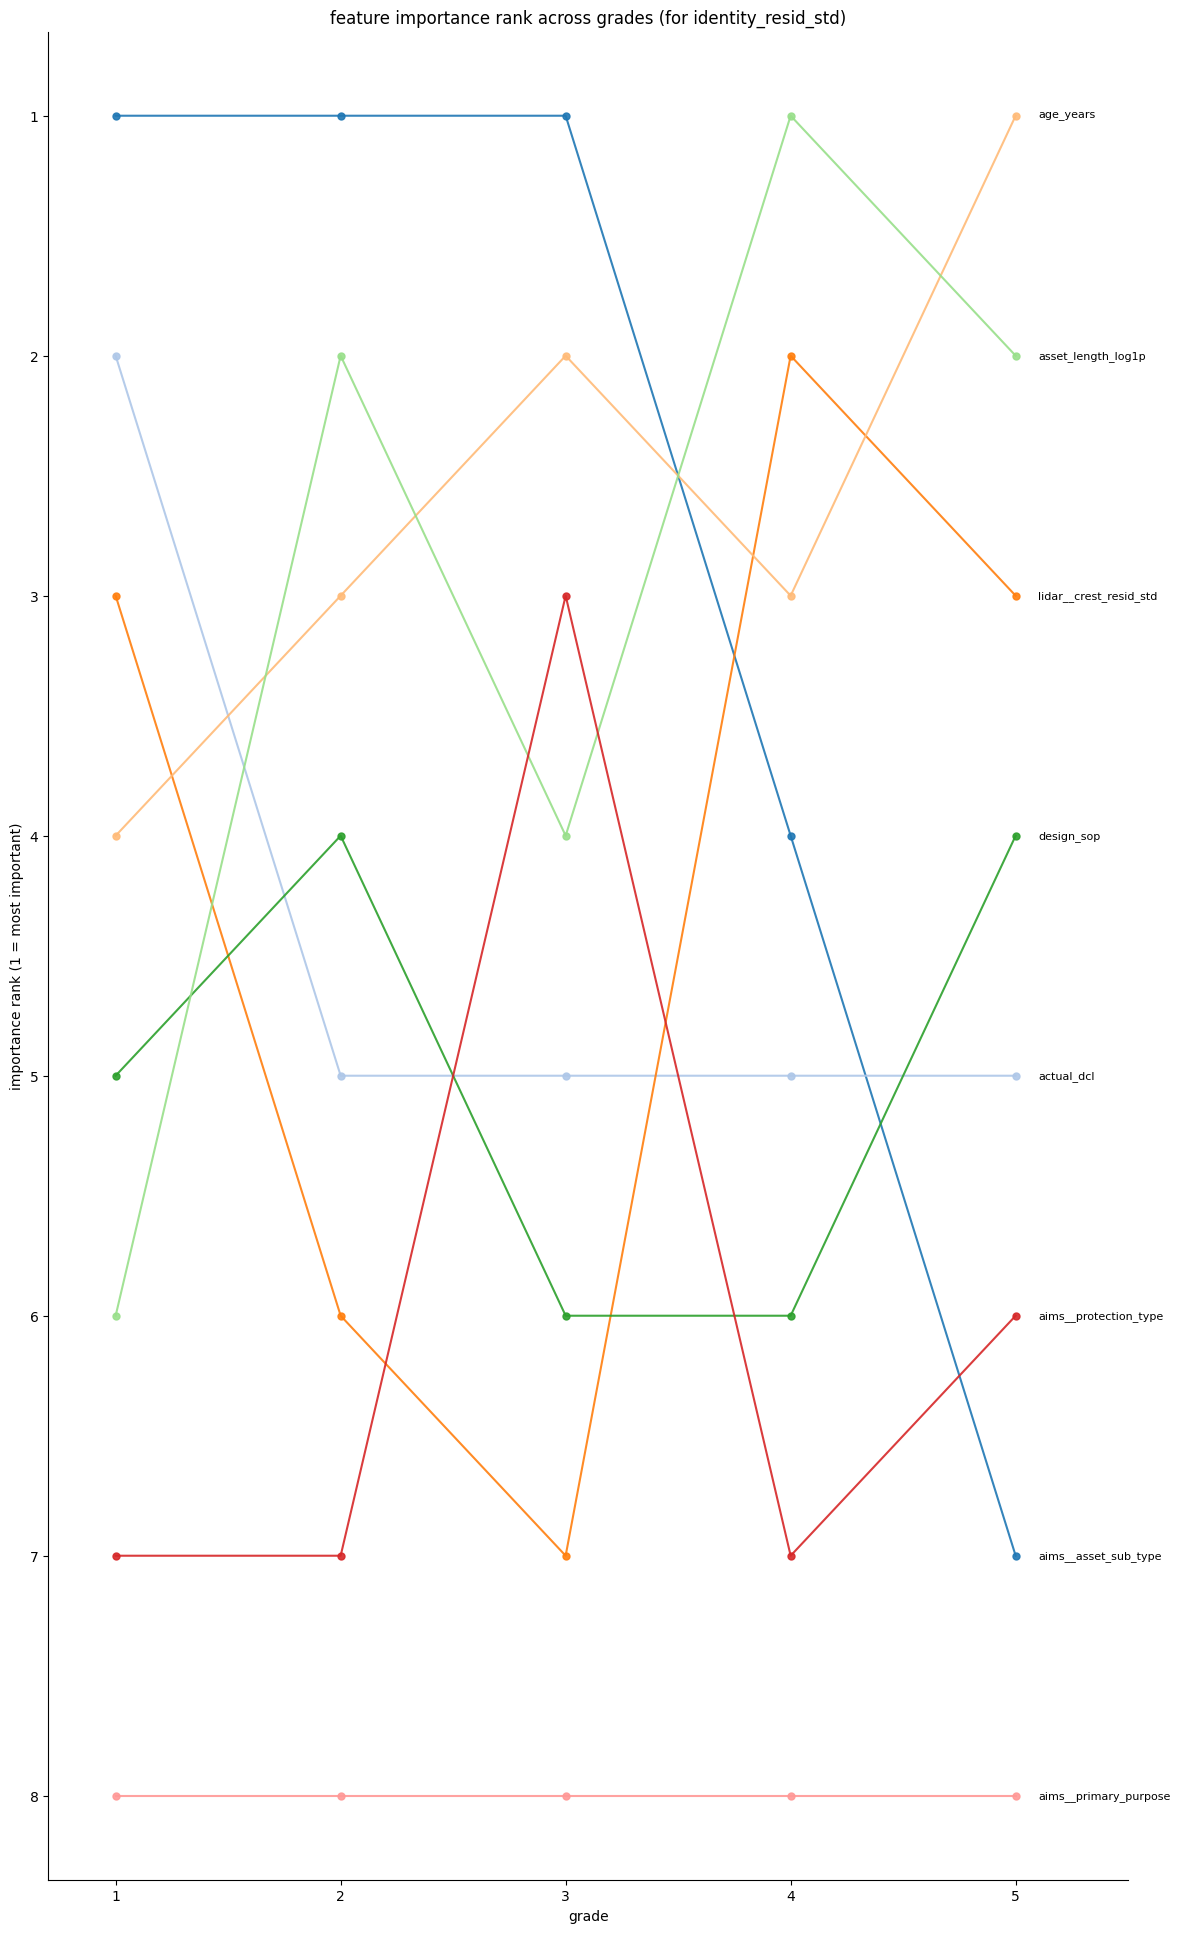

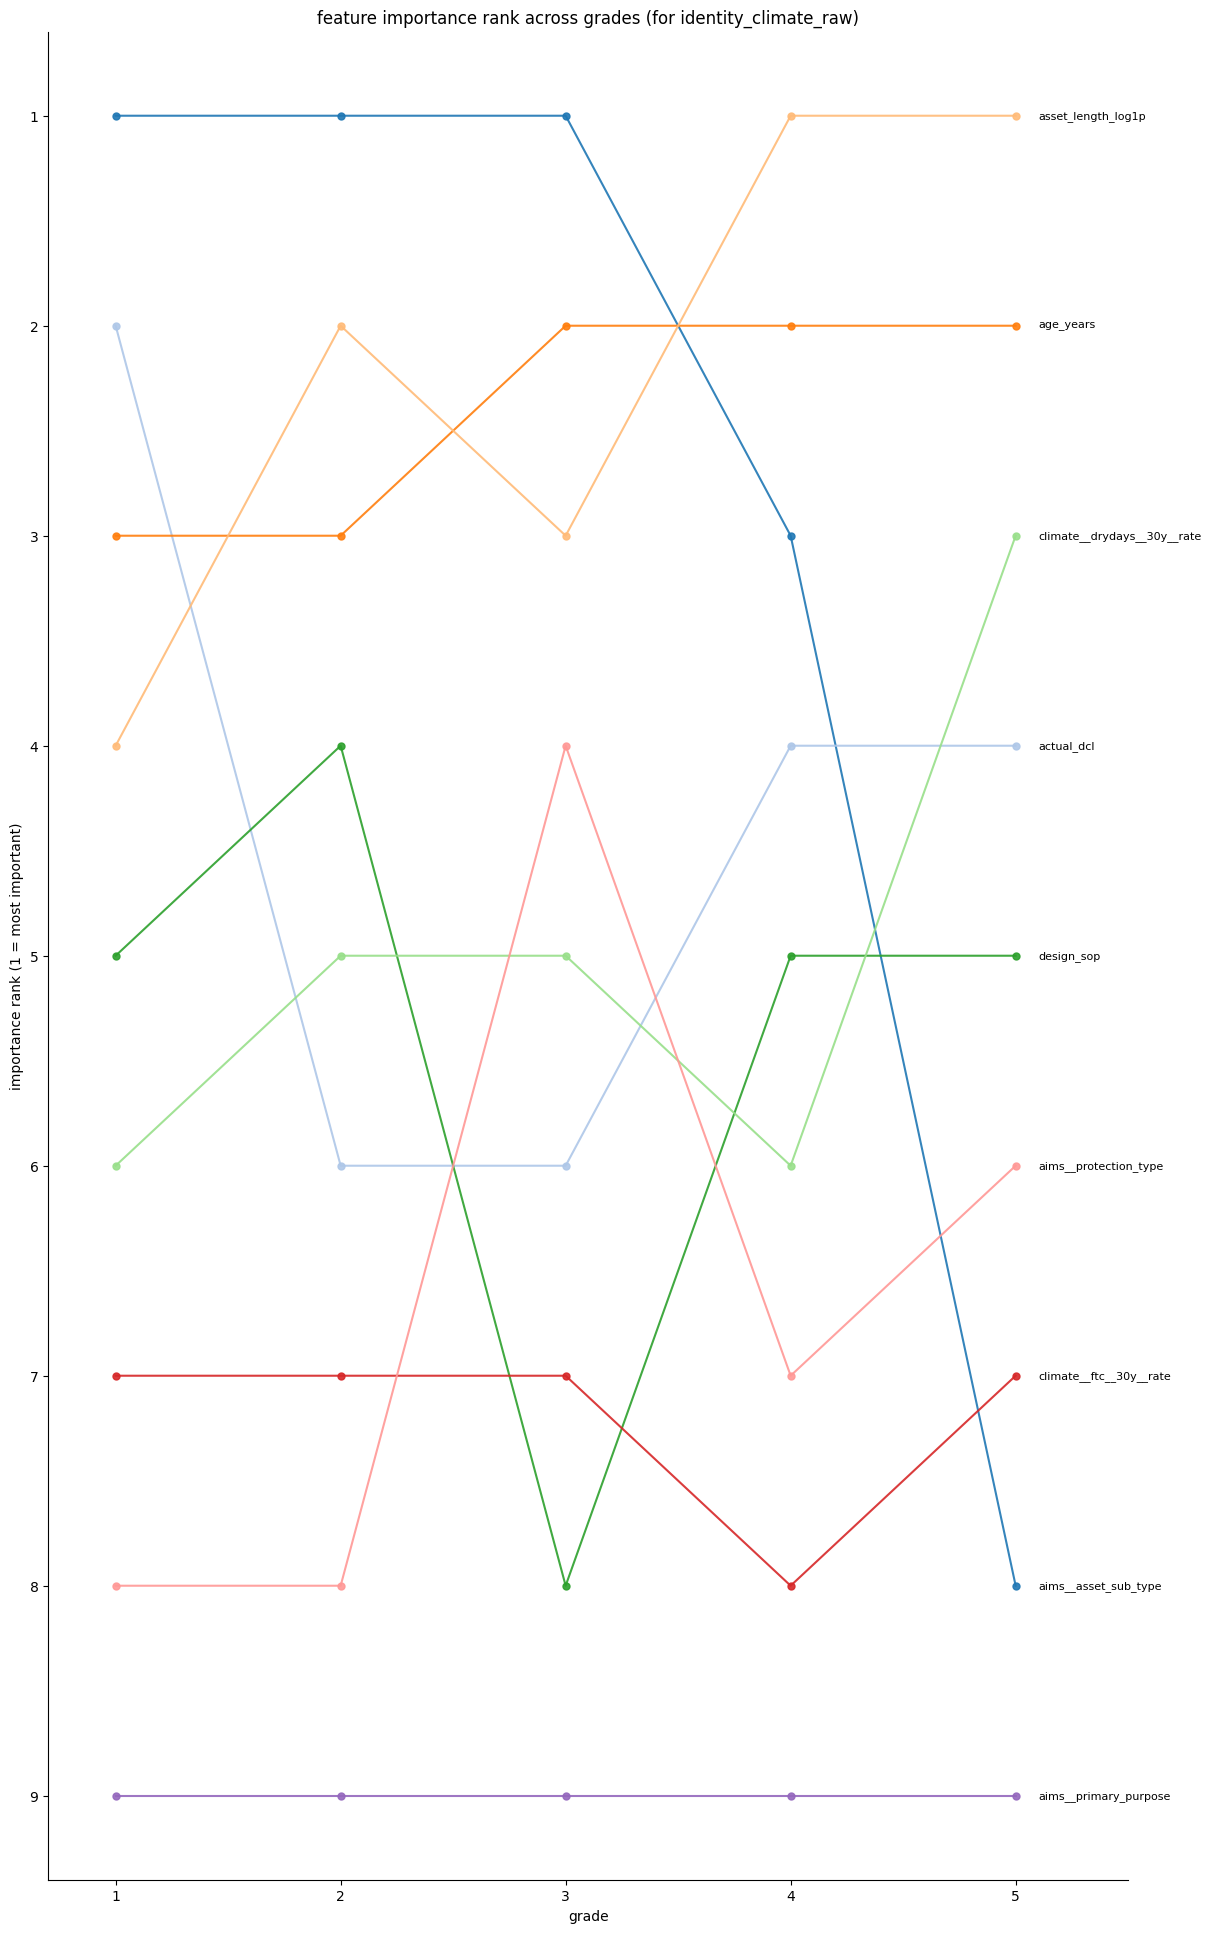

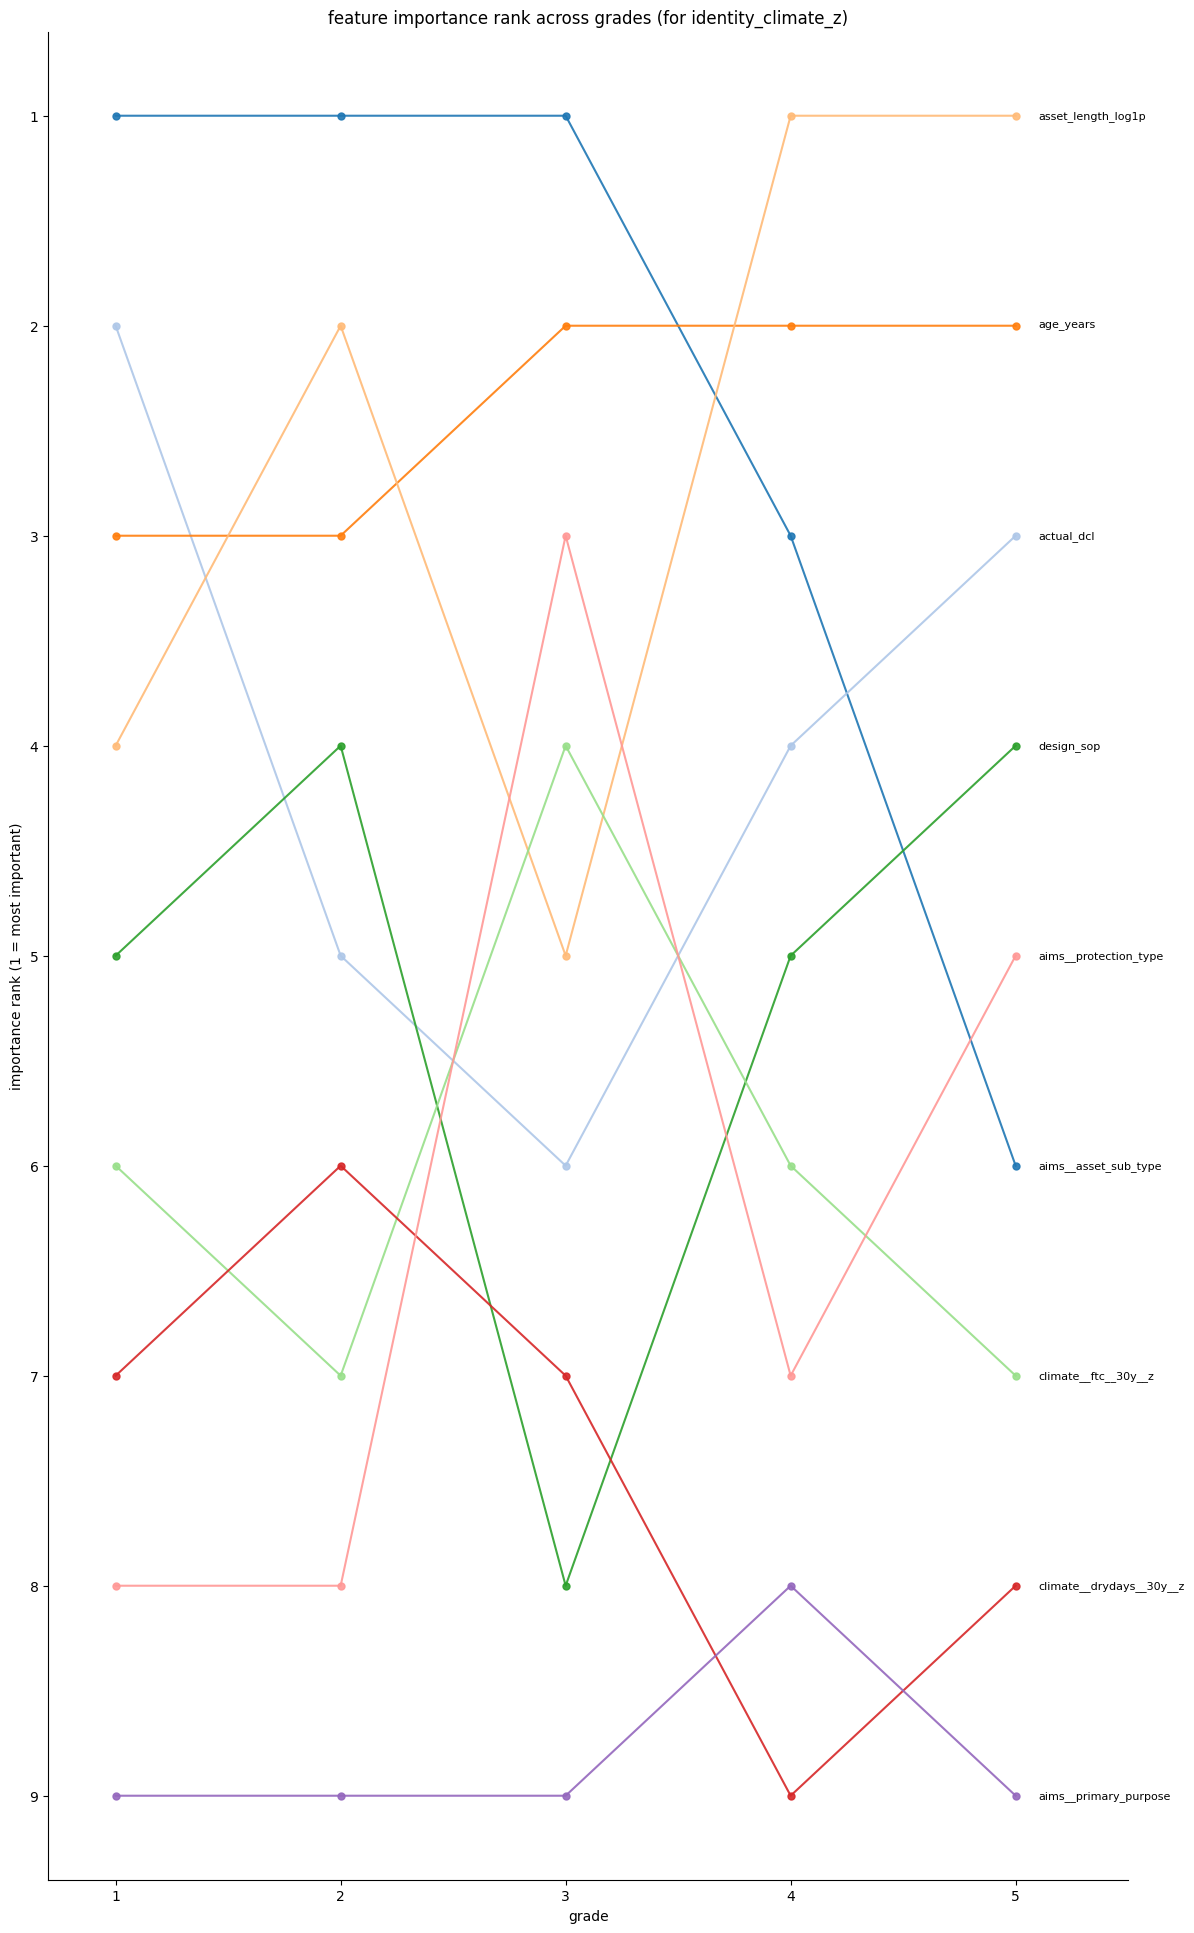

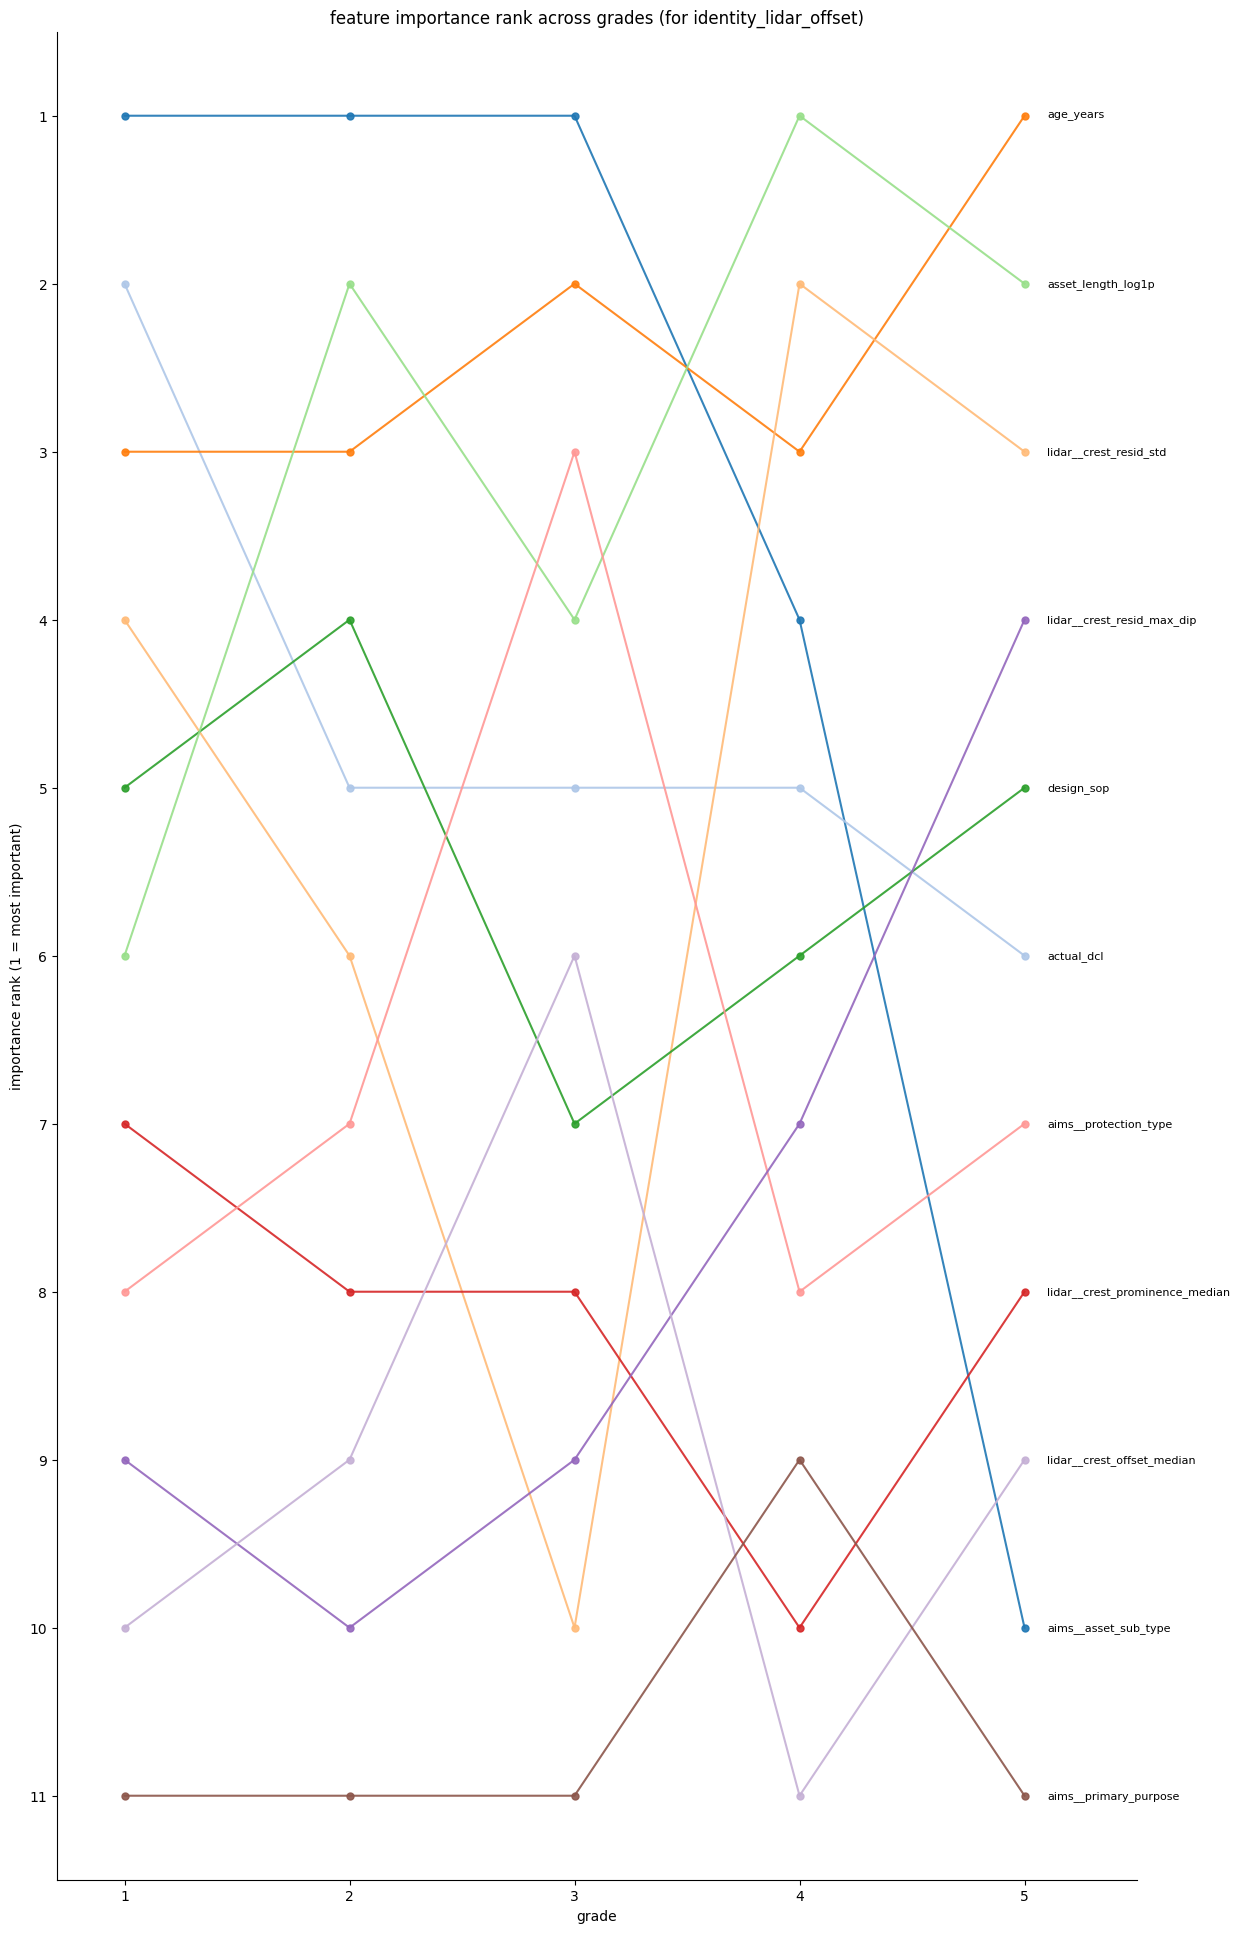

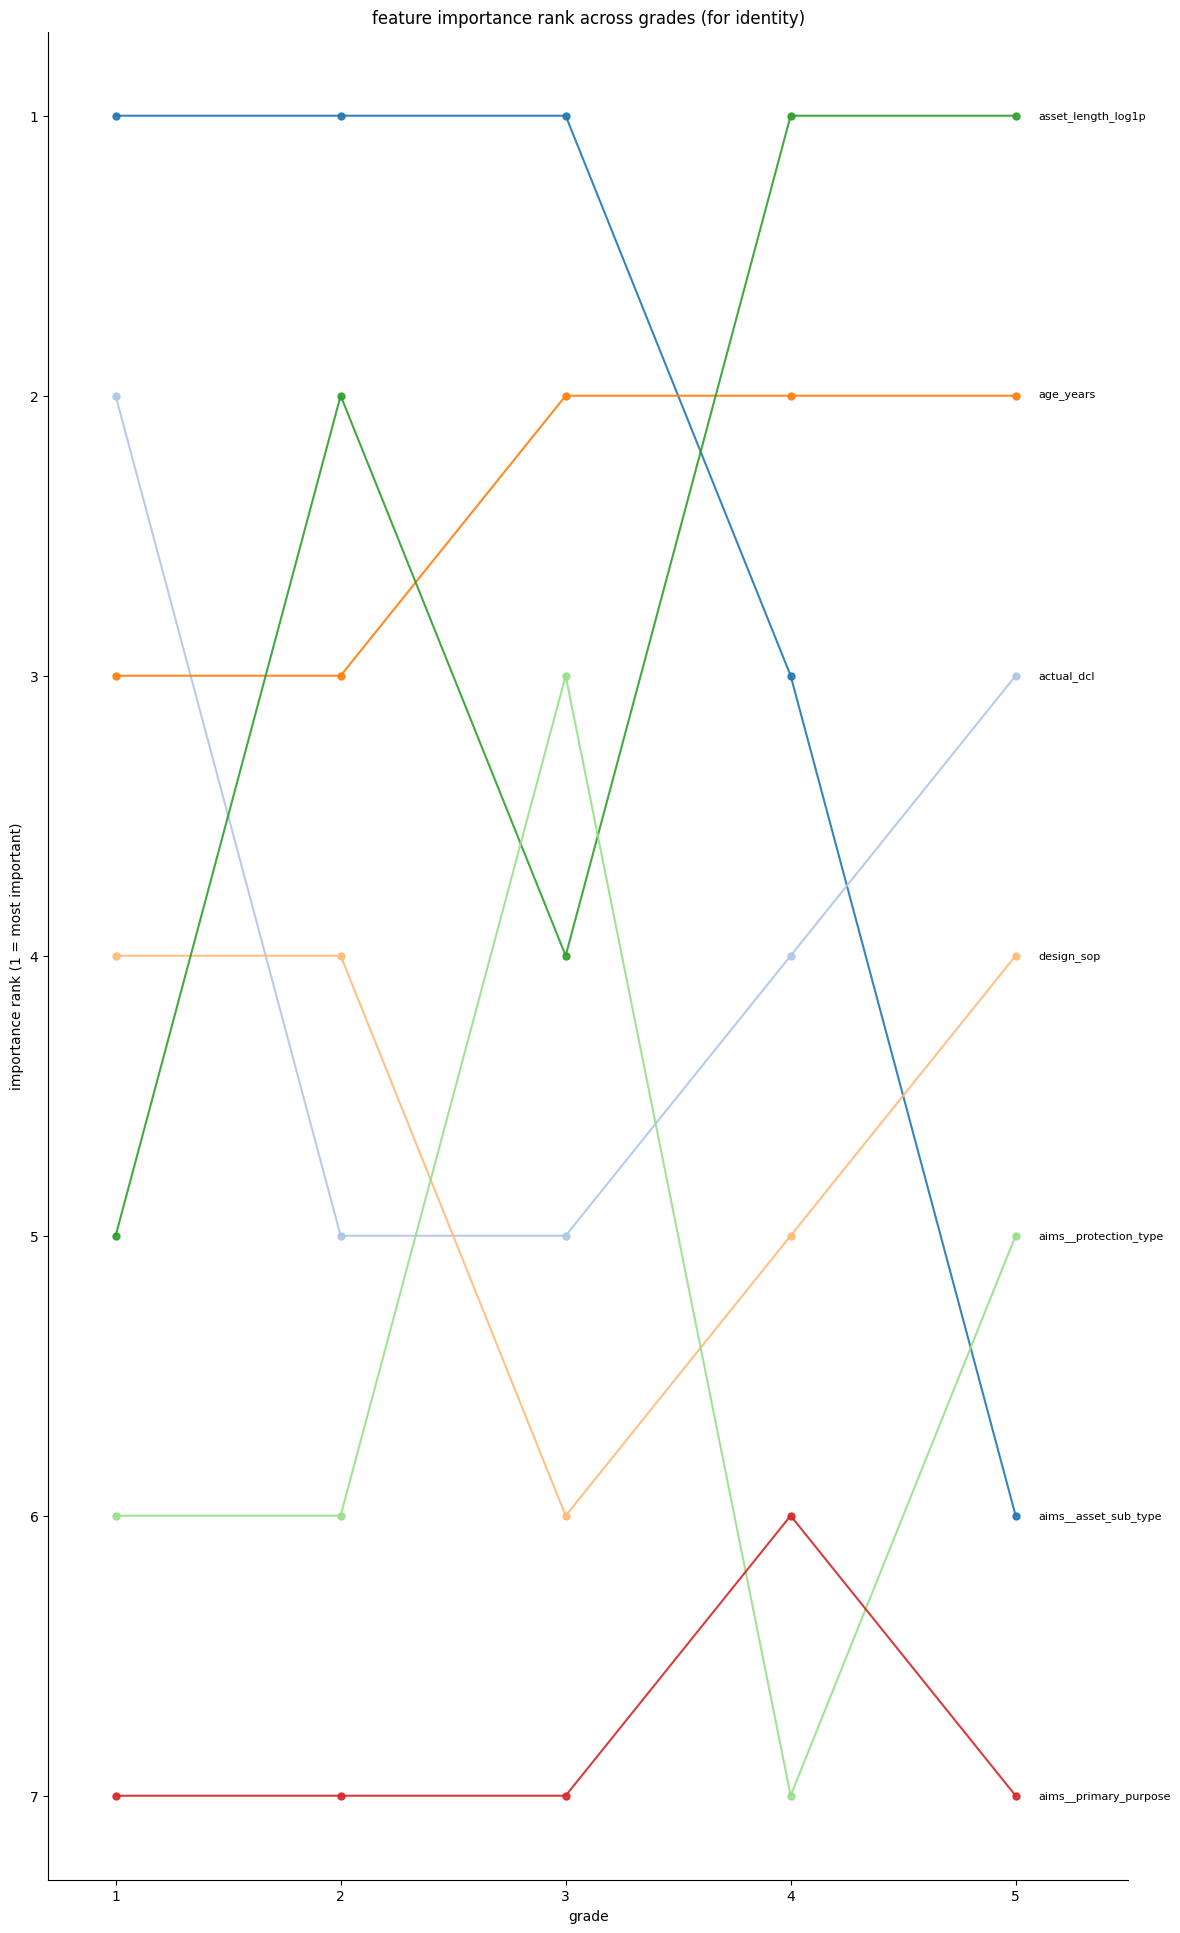

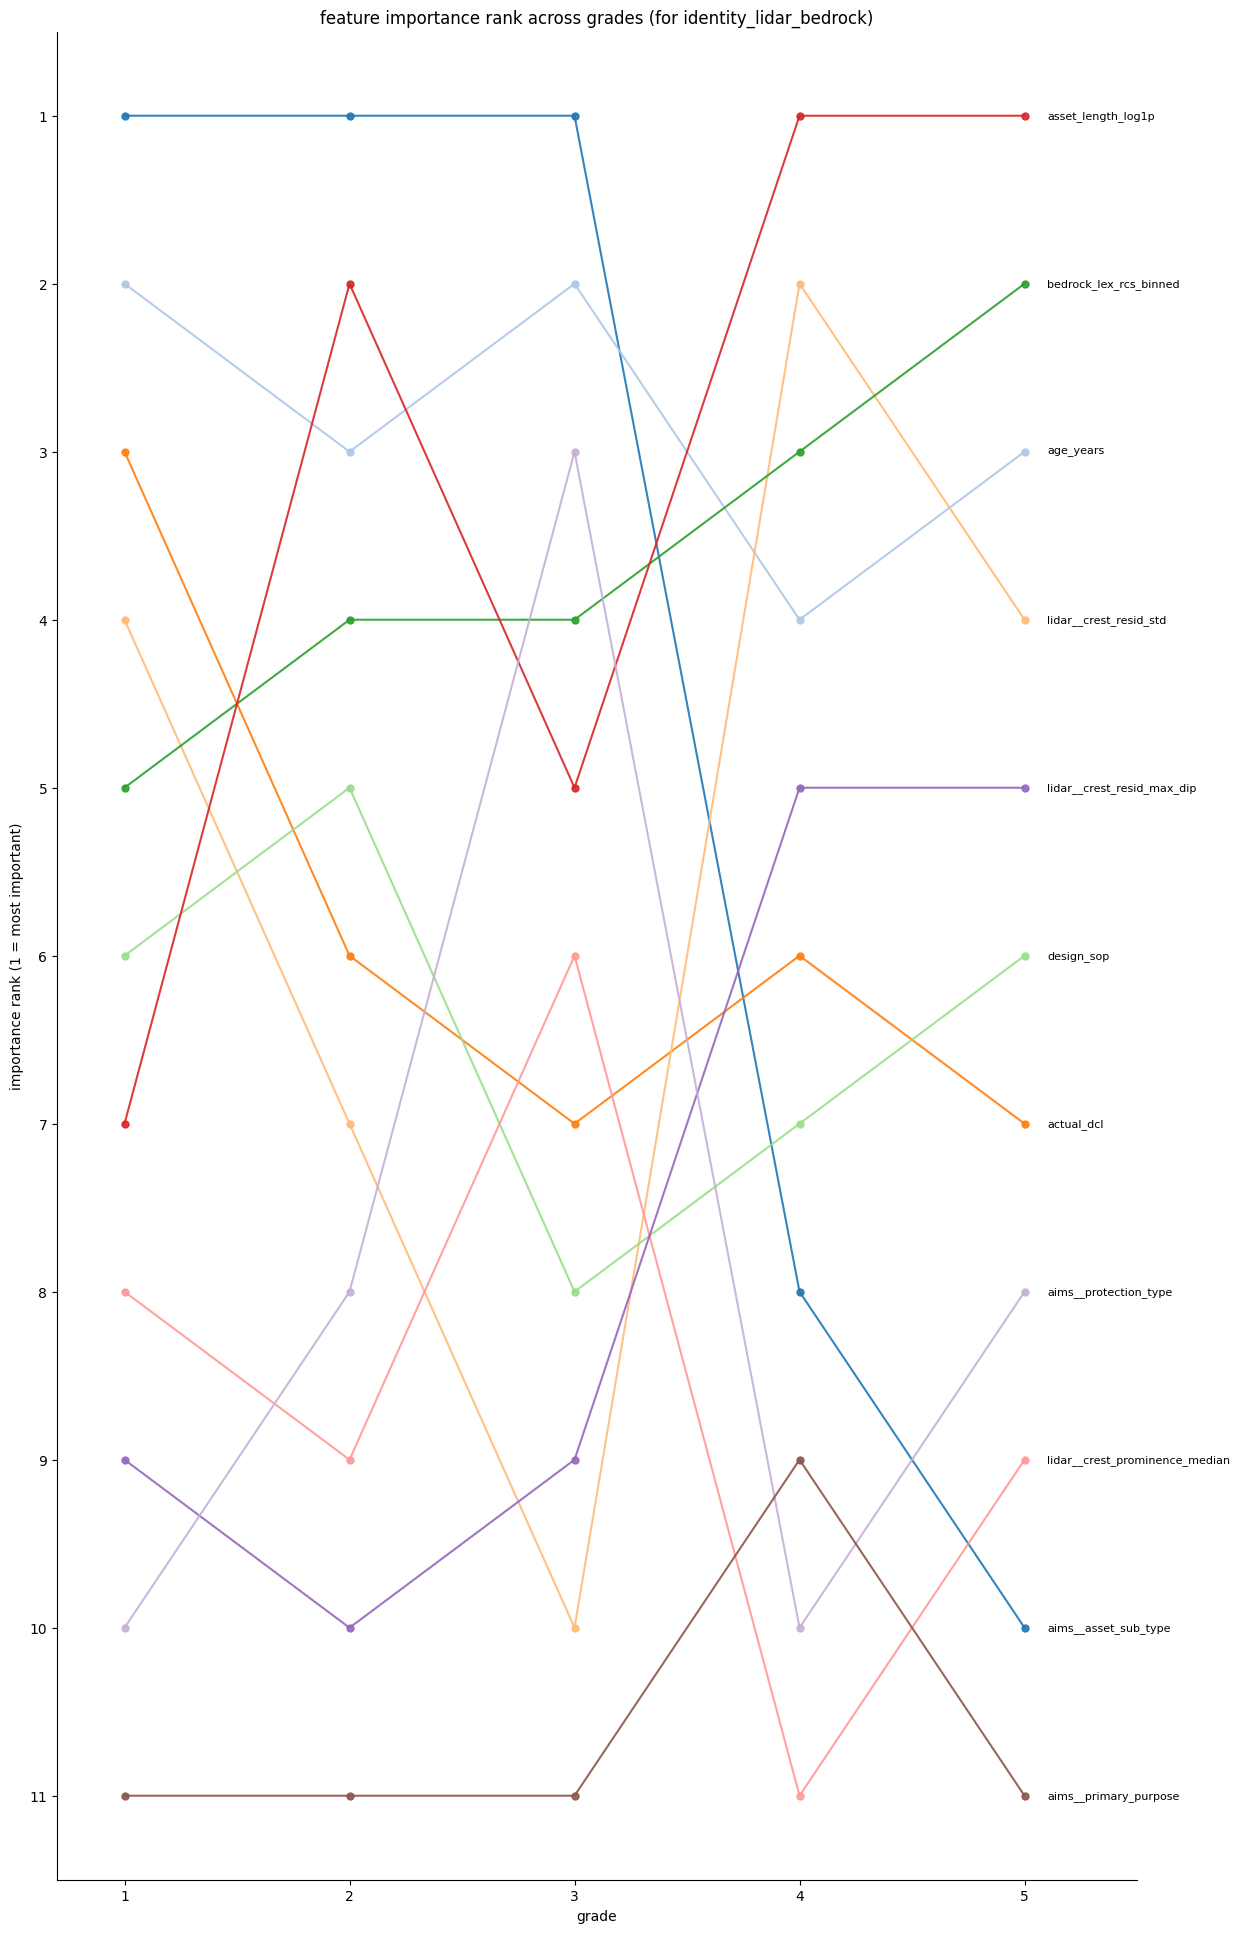

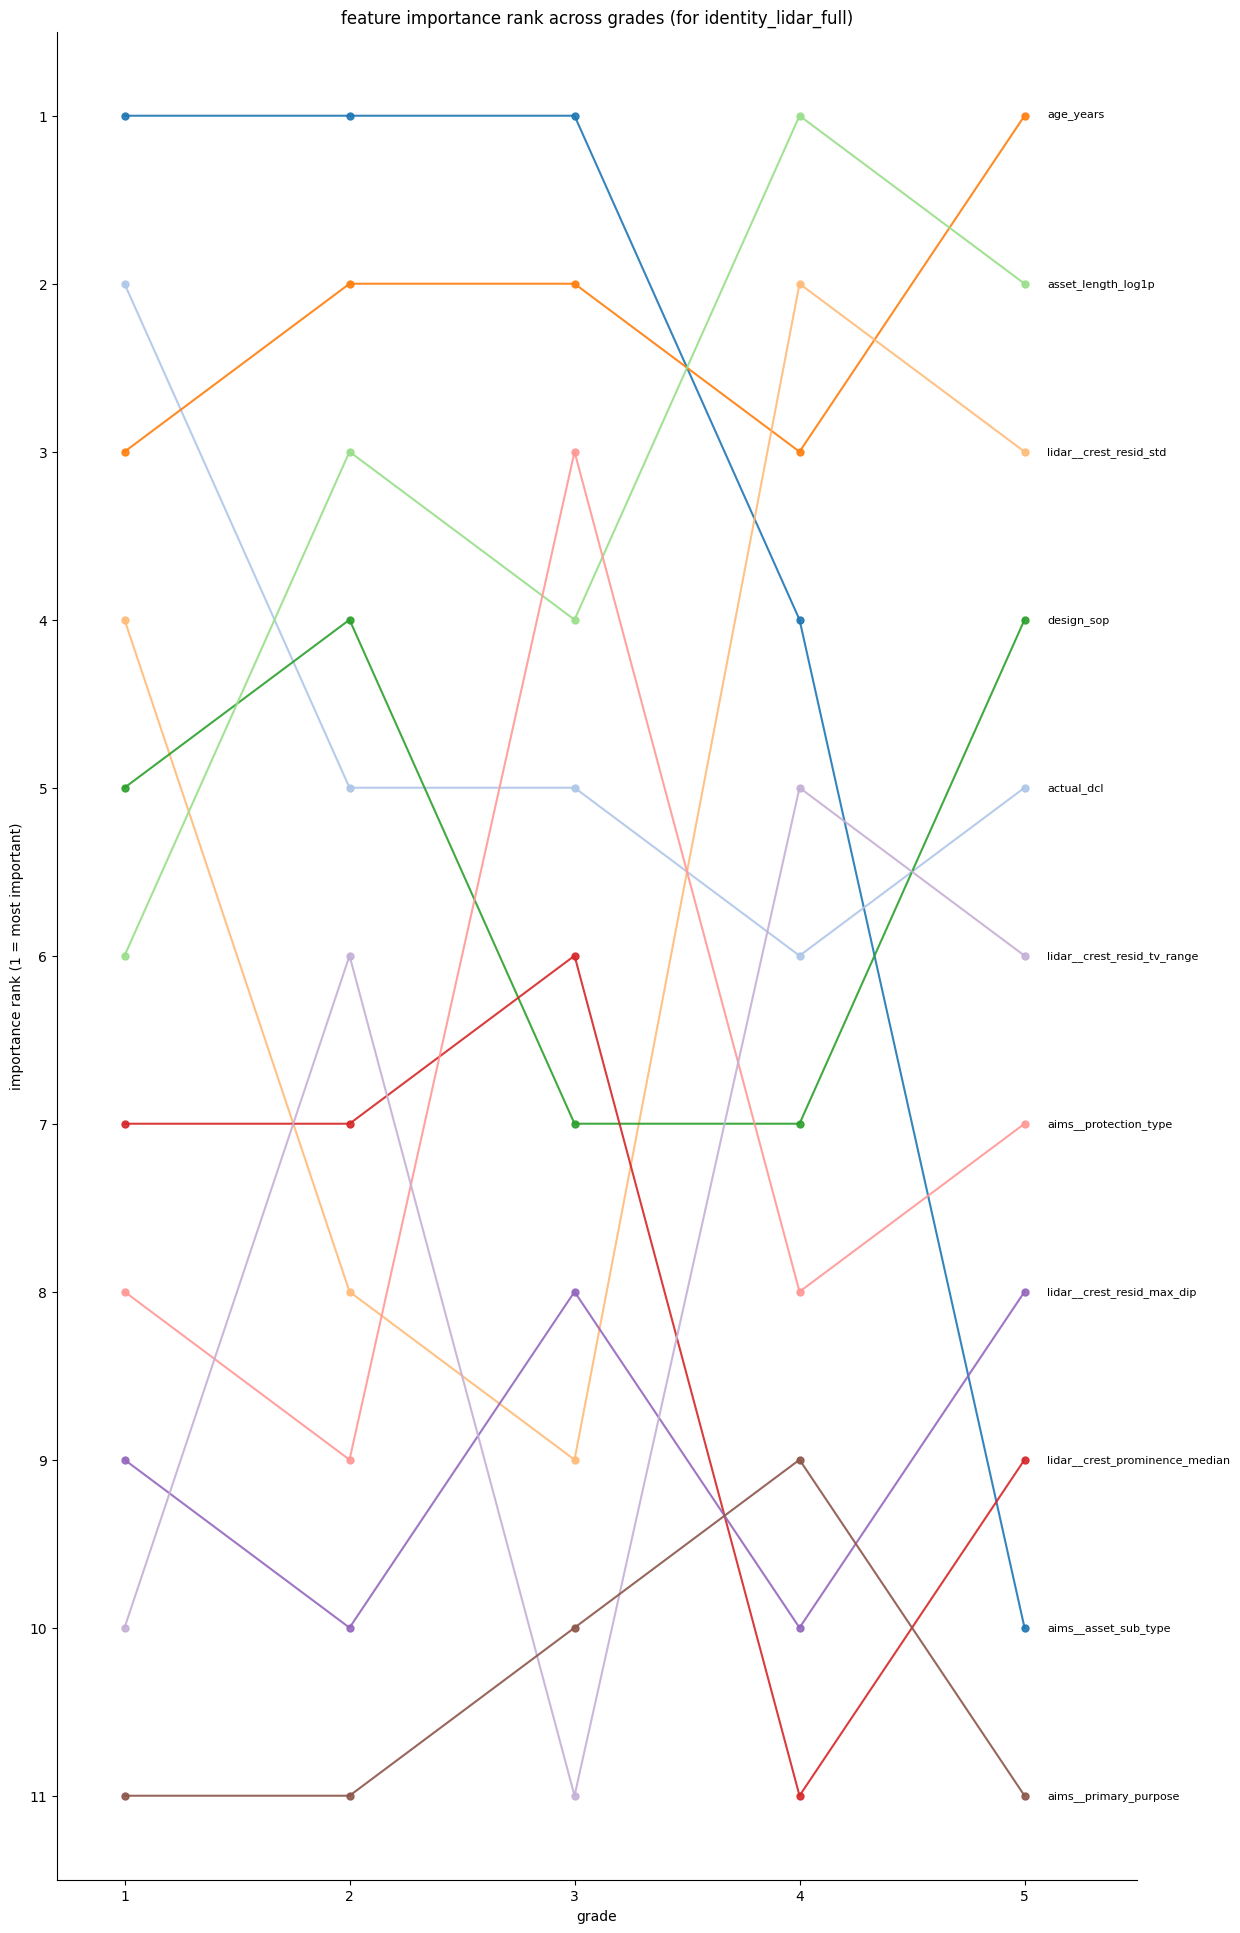

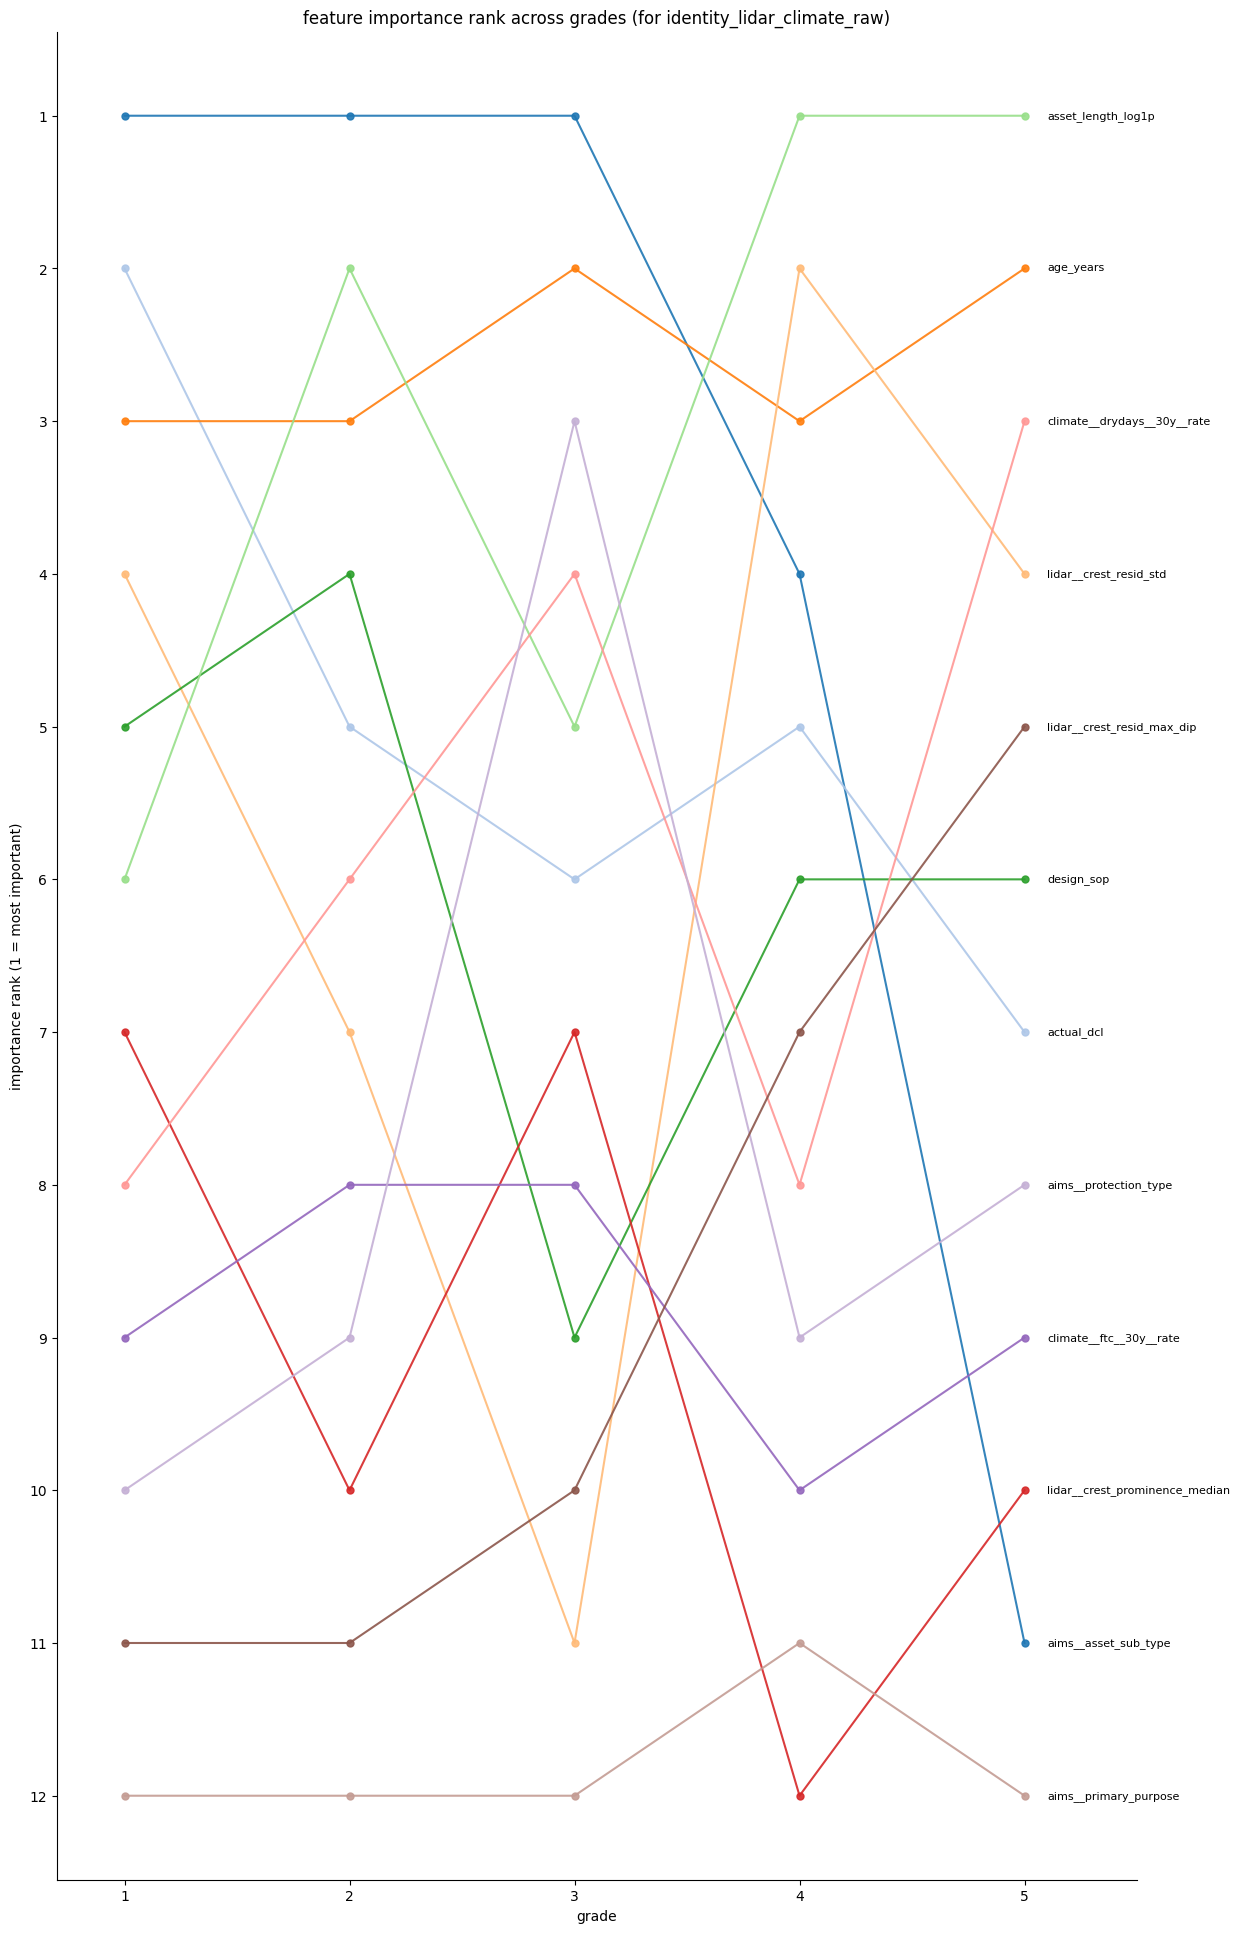

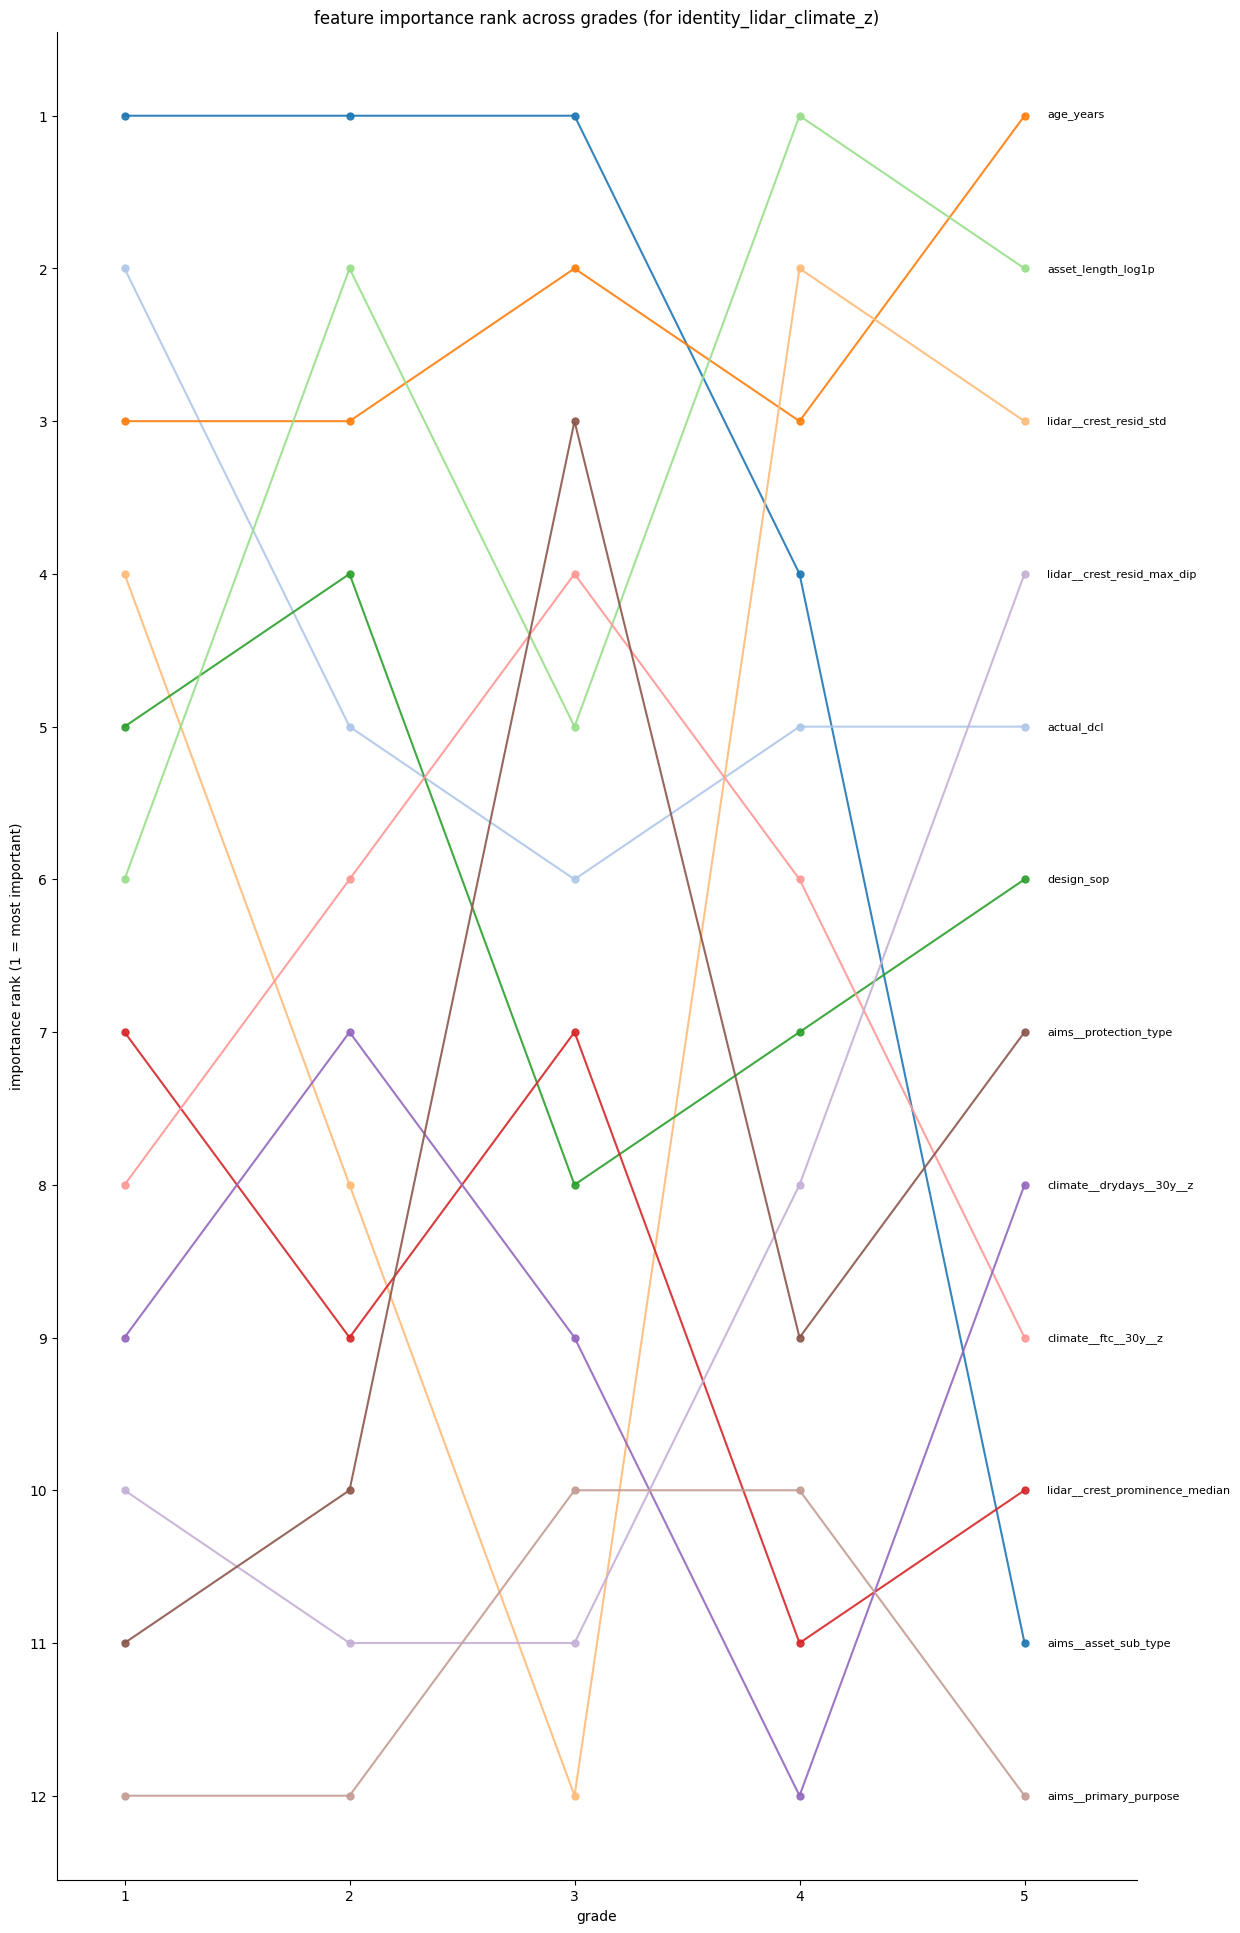

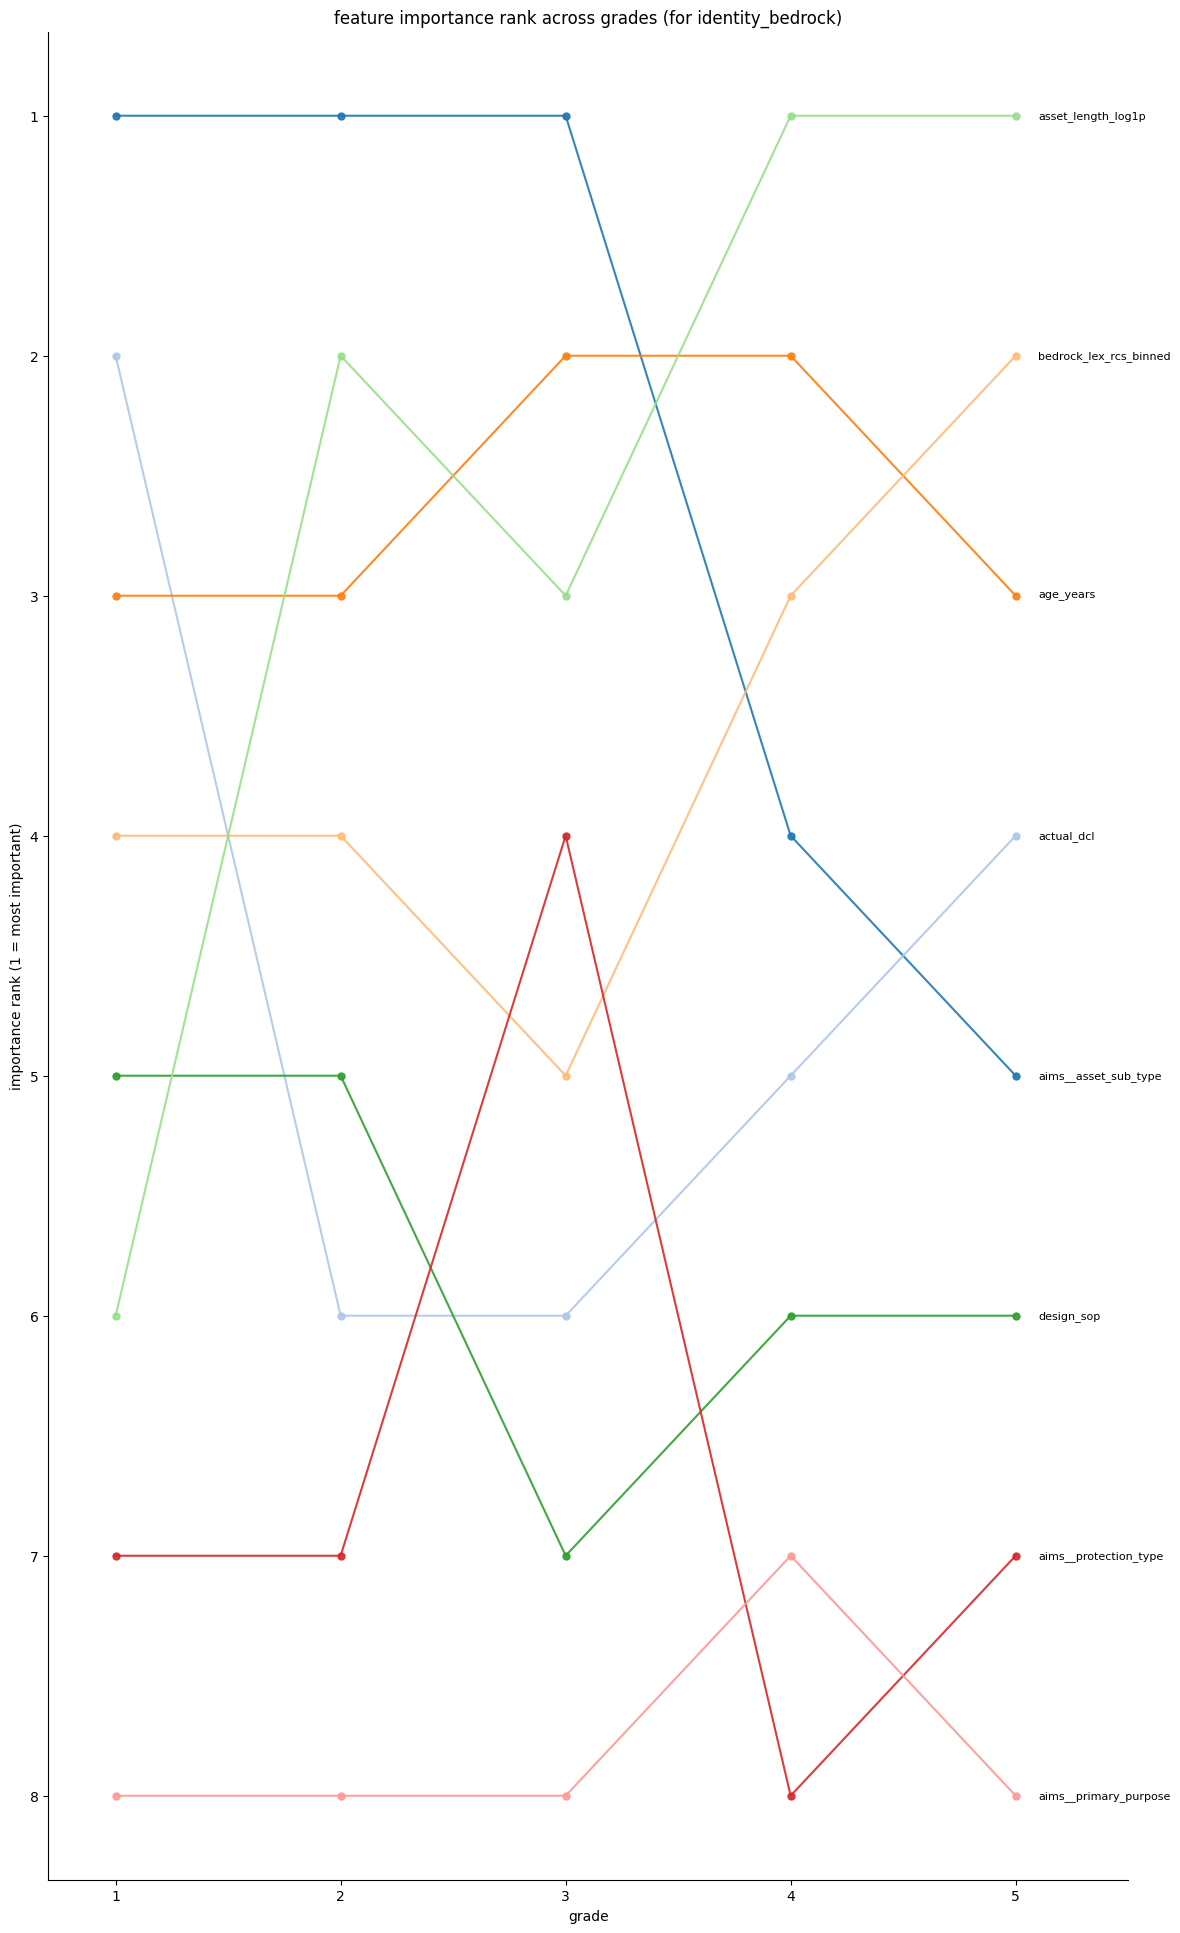

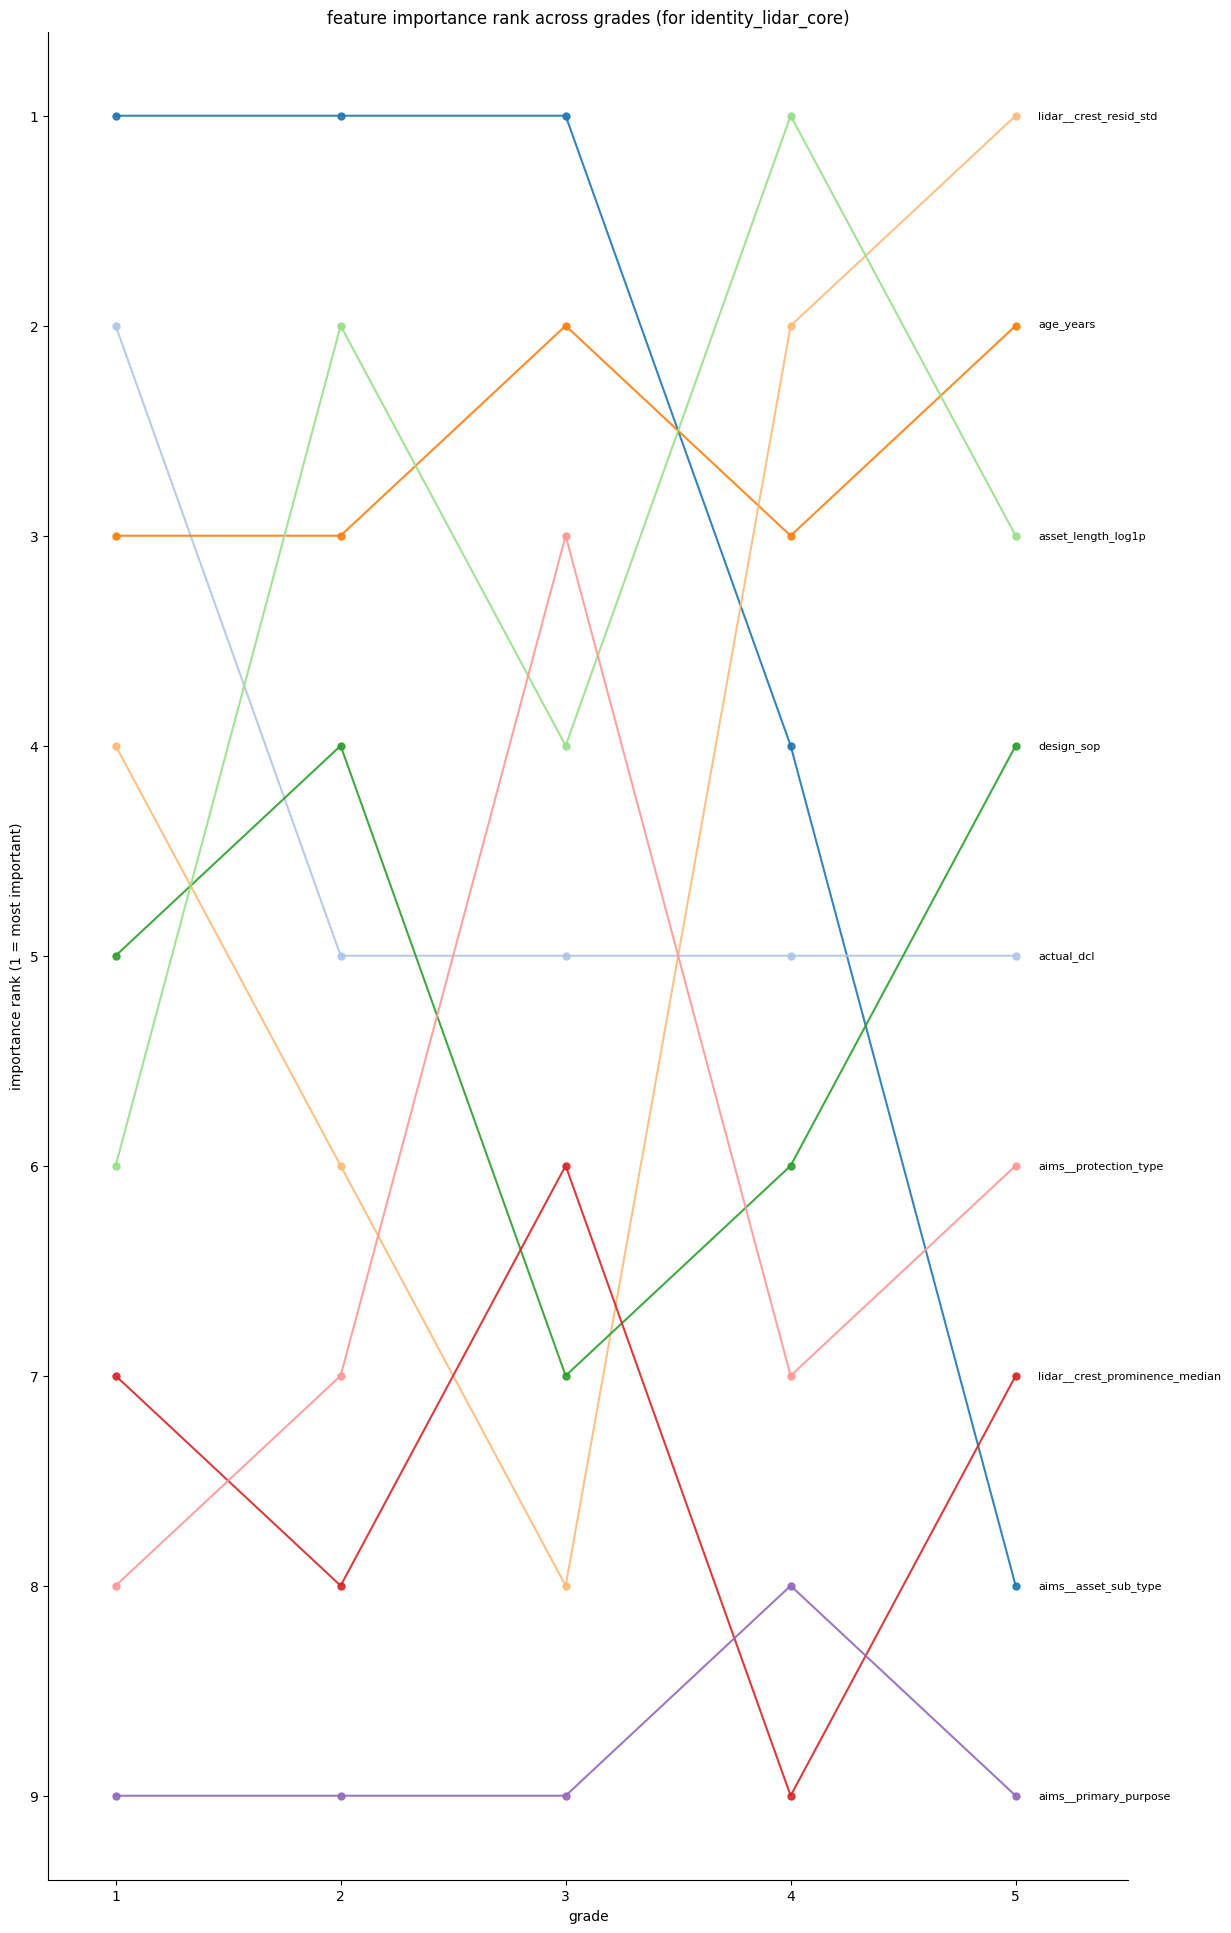

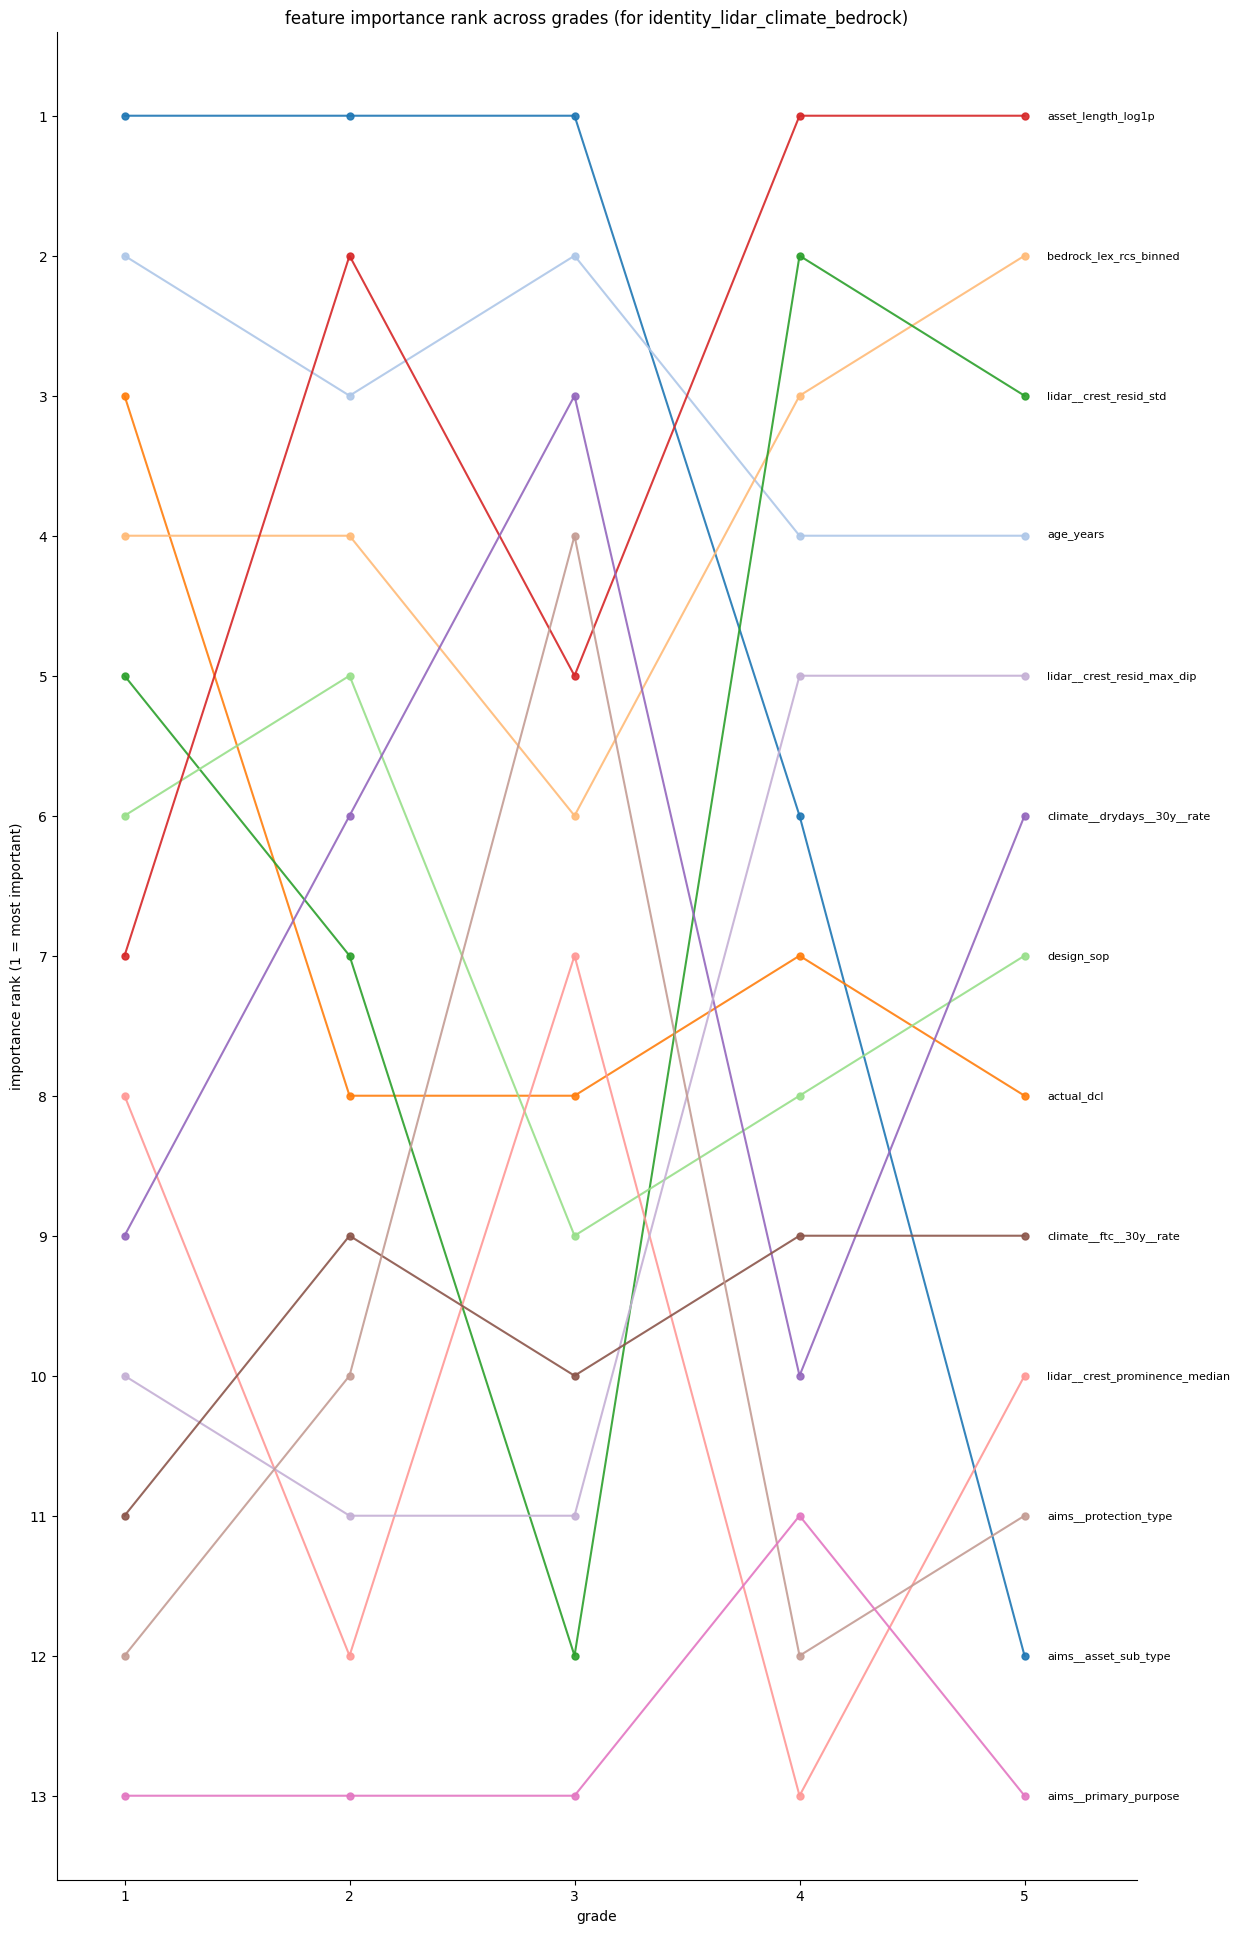

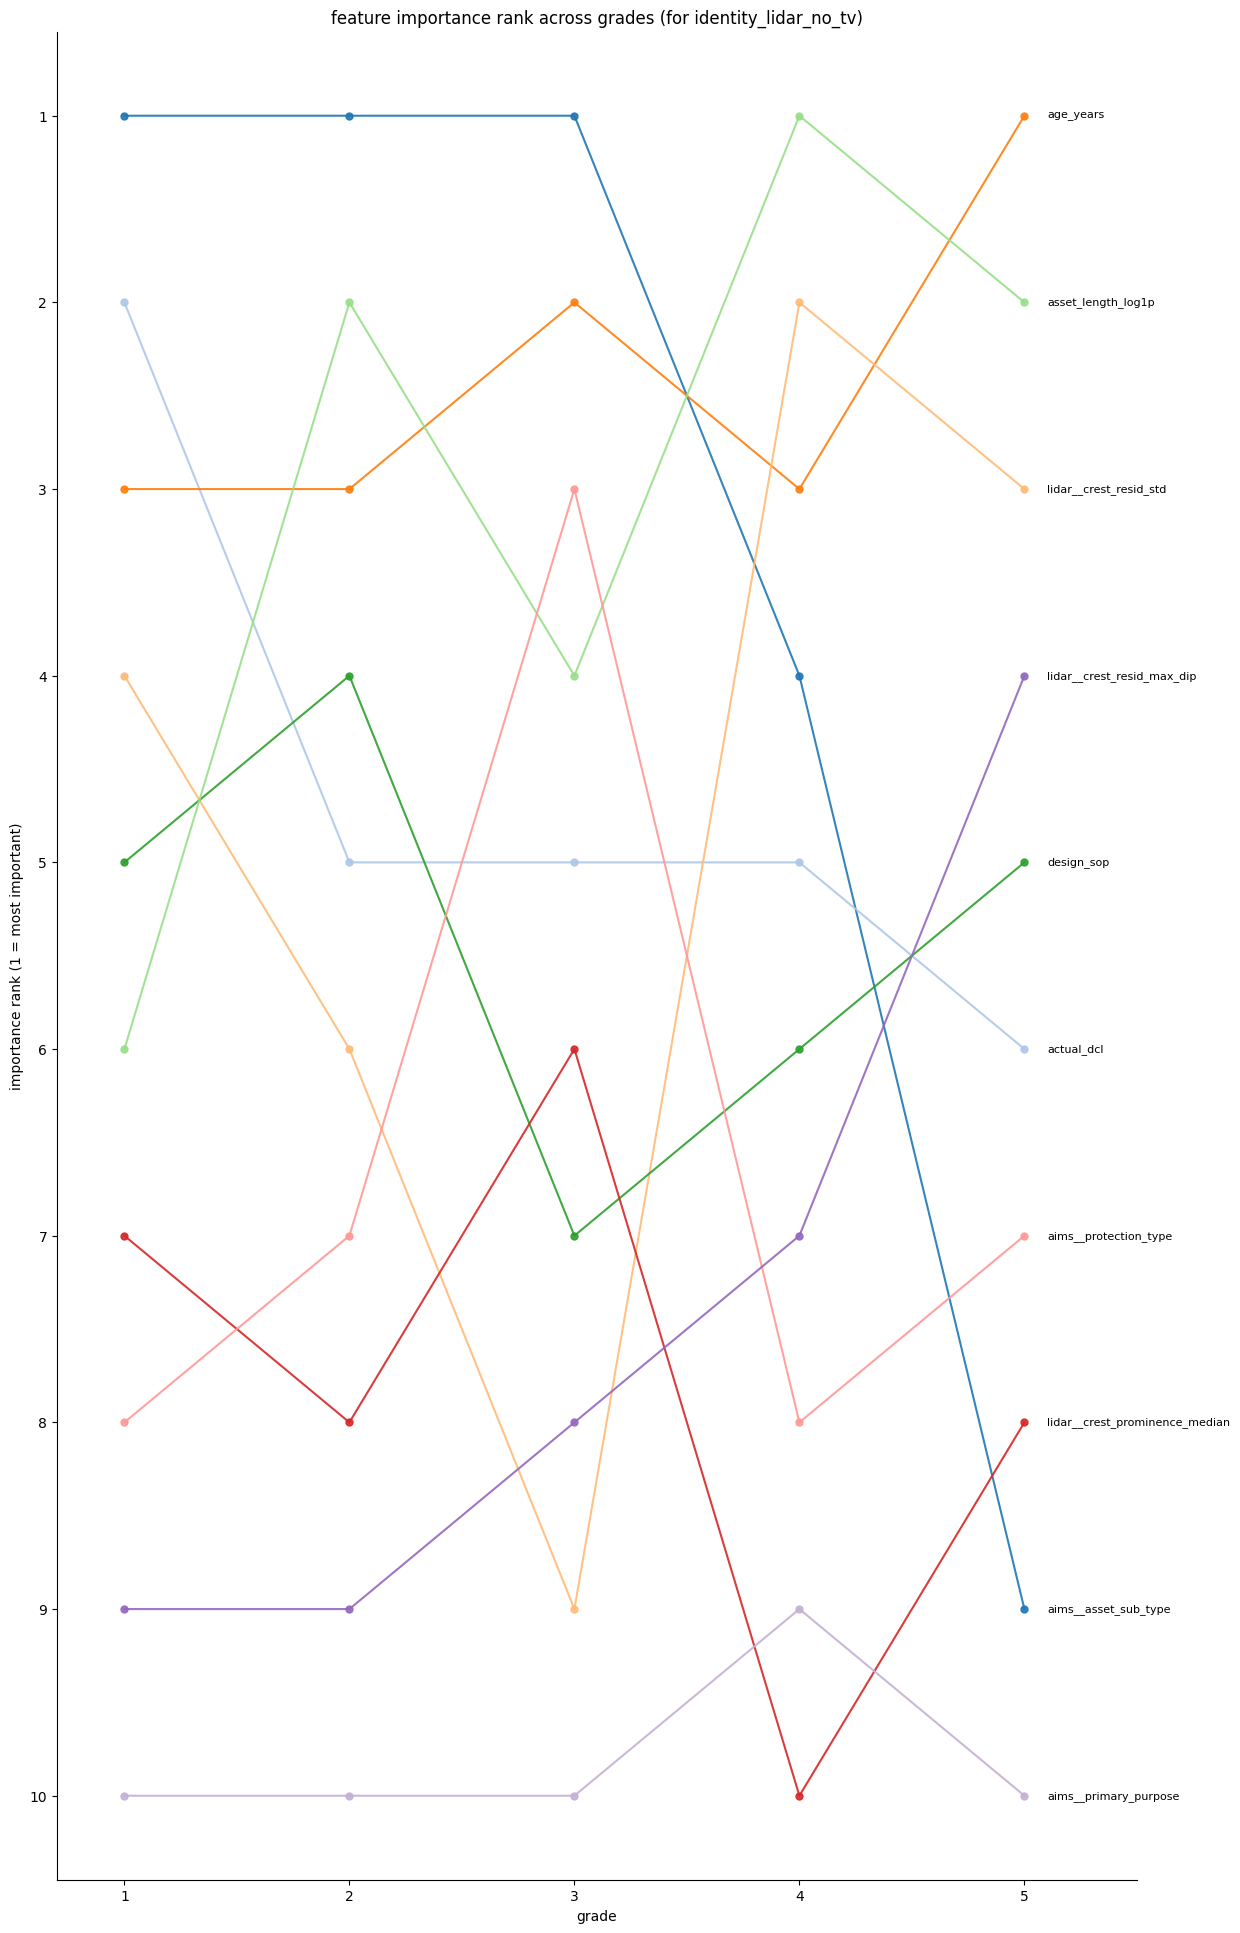

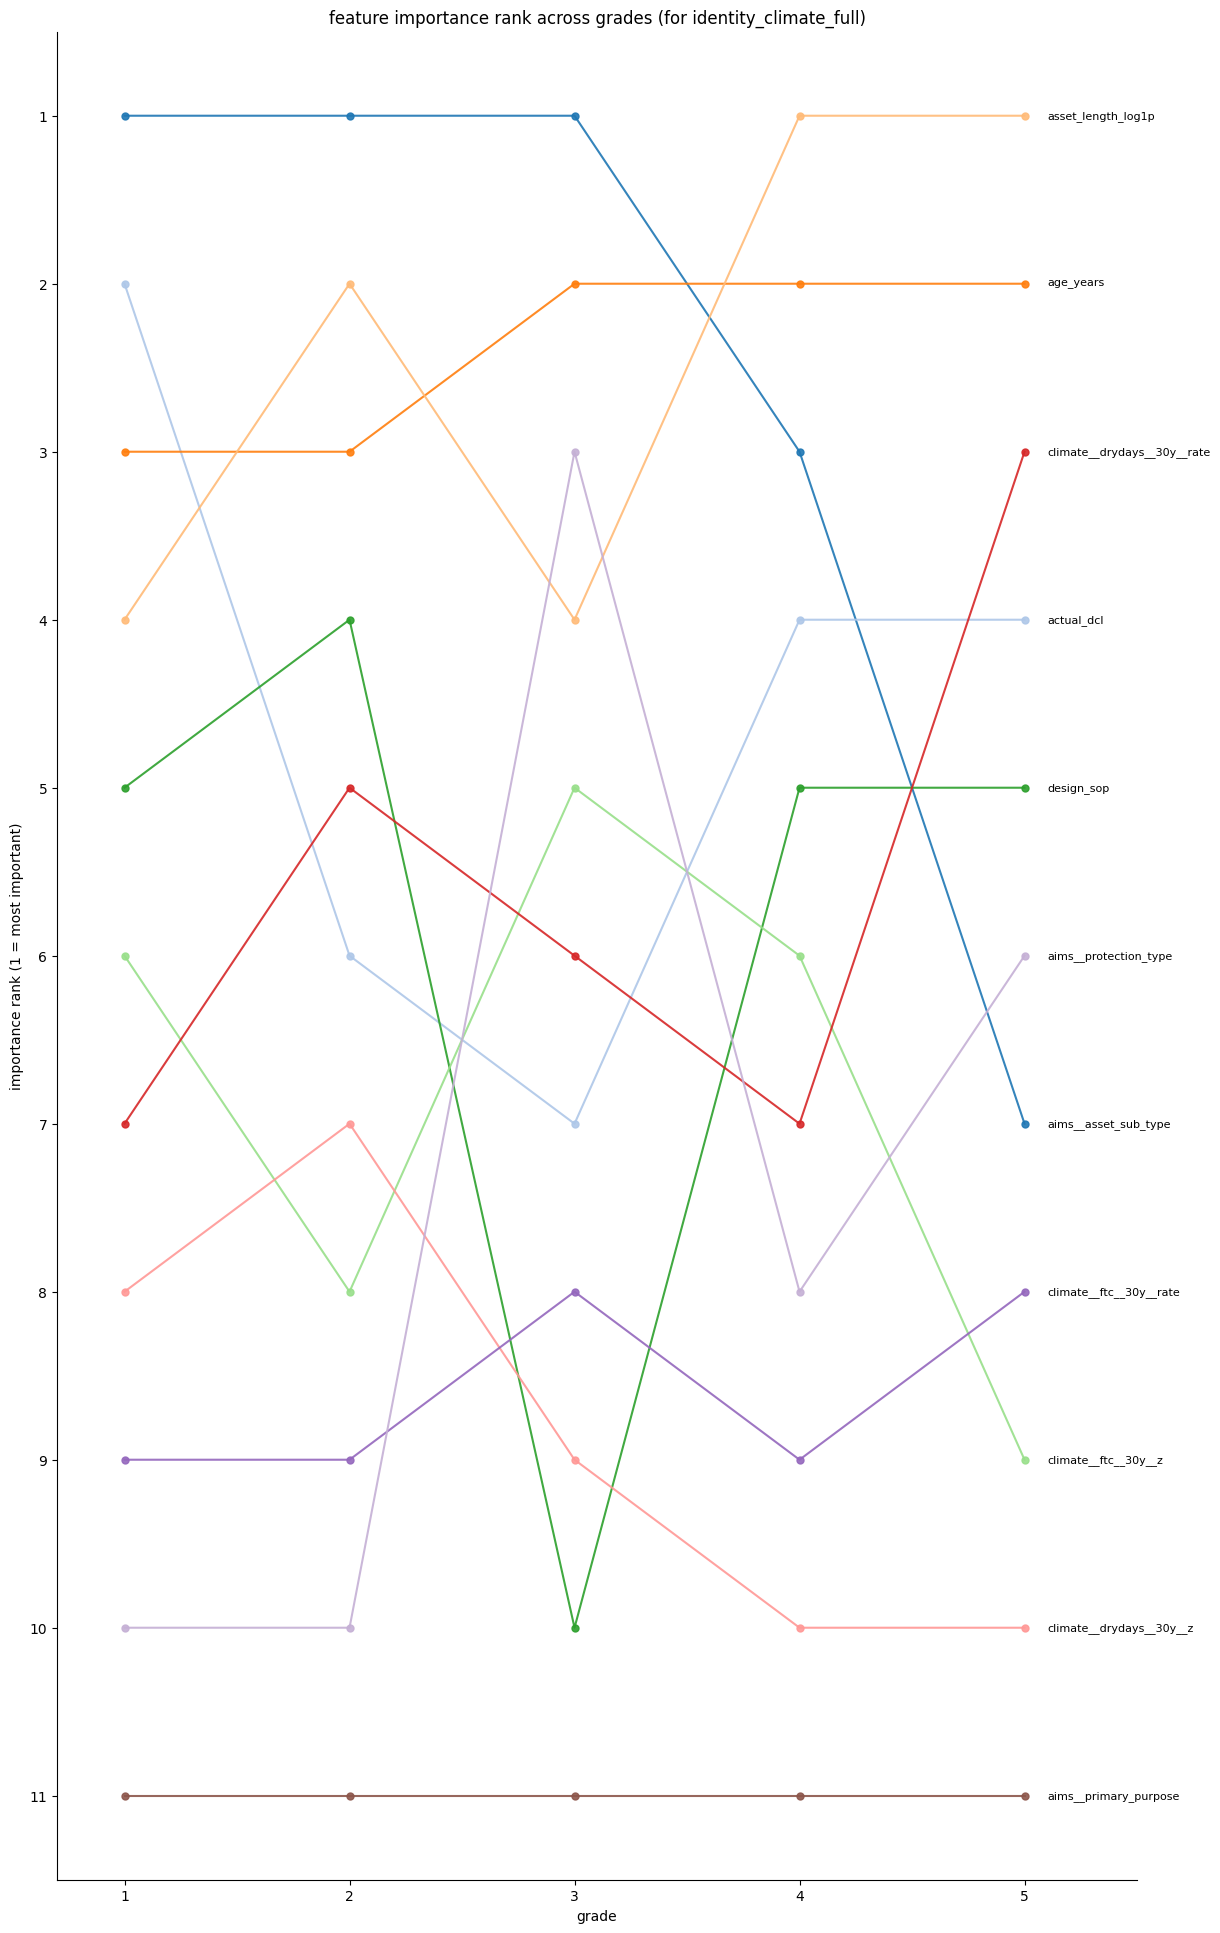

In [41]:
import matplotlib.pyplot as plt 

for feature_set in feature_importance.get_column("composition").unique().to_list():

    bump = (
        feature_importance.filter(pl.col("composition") == feature_set)
        .with_columns(pl.col("mean_abs_shap").rank(descending=True).over("grade").alias("plot_rank"))
        .sort("feature", "grade")
    )

    # print(bump)



    grades = [1, 2, 3, 4, 5]

    # start with order for grade 1 importances

    features = bump.filter(pl.col("grade") == 1).sort("plot_rank").get_column("feature").to_list()


    fig, ax = plt.subplots(figsize=(24, 24))
    fig.subplots_adjust(left=0.25, right=0.70)   # canvas room for the endpoint labels

    cmap = plt.get_cmap("tab20")
    colours = {f: cmap(i % 20) for i, f in enumerate(features)}

    for f in features:
        sub = bump.filter(pl.col("feature") == f).sort("grade")

        xs = sub.get_column("grade").to_list()
        ys = sub.get_column("plot_rank").to_list()

        ax.plot(
            xs, 
            ys, 
            "-o", 
            linewidth=1.5, 
            markersize=5, 
            alpha=0.9,
            c=colours[f]
        )

        # ax.text(
        #     xs[0] - 0.10, 
        #     ys[0], 
        #     f, 
        #     ha="right", 
        #     va="center",
        #     fontsize=8, 
        #     clip_on=False
        # )

        ax.text(
            xs[-1] + 0.10, 
            ys[-1], 
            f, 
            ha="left", 
            va="center",
            fontsize=8, 
            clip_on=False
        )


    ax.set_xticks(grades)
    ax.set_yticks(range(1, len(features) + 1))
    ax.set_xlim(0.7, 5.5)
    ax.invert_yaxis() # rank 1 highest, at the top
    ax.set_xlabel("grade")
    ax.set_ylabel("importance rank (1 = most important)")
    ax.set_title(f"feature importance rank across grades (for {feature_set})")
    ax.spines[["top", "right"]].set_visible(False)

    plt.show()

In [44]:
cell_summary_nd.columns

['cell_id',
 'f1_for_grade_1',
 'f1_for_grade_2',
 'f1_for_grade_3',
 'f1_for_grade_4',
 'f1_for_grade_5',
 'macro_f1',
 'mae',
 'pr_auc_ge4',
 'precision_for_grade_1',
 'precision_for_grade_2',
 'precision_for_grade_3',
 'precision_for_grade_4',
 'precision_for_grade_5',
 'qwk',
 'recall_for_grade_1',
 'recall_for_grade_2',
 'recall_for_grade_3',
 'recall_for_grade_4',
 'recall_for_grade_5',
 'model',
 'composition',
 'capacity',
 'wants_full_shap',
 'seconds_fit',
 'seconds_shap',
 'seconds_total',
 'learning_rate',
 'max_iter',
 'max_leaf_nodes',
 'max_depth',
 'l2_regularization',
 'min_samples_leaf',
 'config_key']

In [45]:
axes = ["capacity", "learning_rate", "max_iter", "max_leaf_nodes", "min_samples_leaf", "l2_regularization"]

axis_effect = (
    cell_summary_nd.filter(pl.col("composition").is_not_null())
    .with_columns(pl.col(axes).cast(pl.Float64))
    .unpivot(
        index=["composition", "cell_id", "pr_auc_ge4", "qwk"],
        on=axes,
        variable_name="axis",
        value_name="level",
    )
    .group_by("axis", "level")
    .agg(
        pl.col("pr_auc_ge4").mean().alias("pr_auc"),
        pl.col("qwk").mean().alias("qwk"),
        pl.len().alias("n_cells"),
    )
    .sort("axis", "level")
)

axis_effect

axis,level,pr_auc,qwk,n_cells
str,f64,f64,f64,u32
"""capacity""",0.4,0.172624,0.093632,1274
"""capacity""",0.8,0.174846,0.211358,1764
"""capacity""",1.6,0.179323,0.26034,1764
"""capacity""",2.5,0.180796,0.274826,1764
"""capacity""",5.0,0.180725,0.283865,1764
…,…,…,…,…
"""max_leaf_nodes""",8.0,0.179179,0.237795,2520
"""max_leaf_nodes""",16.0,0.180124,0.247213,2520
"""min_samples_leaf""",1.0,0.17744,0.231338,2786


In [46]:
with pl.Config(tbl_rows=-1):
    print(axis_effect)

shape: (26, 5)
┌───────────────────┬───────┬──────────┬──────────┬─────────┐
│ axis              ┆ level ┆ pr_auc   ┆ qwk      ┆ n_cells │
│ ---               ┆ ---   ┆ ---      ┆ ---      ┆ ---     │
│ str               ┆ f64   ┆ f64      ┆ f64      ┆ u32     │
╞═══════════════════╪═══════╪══════════╪══════════╪═════════╡
│ capacity          ┆ 0.4   ┆ 0.172624 ┆ 0.093632 ┆ 1274    │
│ capacity          ┆ 0.8   ┆ 0.174846 ┆ 0.211358 ┆ 1764    │
│ capacity          ┆ 1.6   ┆ 0.179323 ┆ 0.26034  ┆ 1764    │
│ capacity          ┆ 2.5   ┆ 0.180796 ┆ 0.274826 ┆ 1764    │
│ capacity          ┆ 5.0   ┆ 0.180725 ┆ 0.283865 ┆ 1764    │
│ l2_regularization ┆ 0.0   ┆ 0.177271 ┆ 0.233132 ┆ 4172    │
│ l2_regularization ┆ 1.0   ┆ 0.178649 ┆ 0.231906 ┆ 4158    │
│ learning_rate     ┆ 0.025 ┆ 0.179214 ┆ 0.233467 ┆ 2688    │
│ learning_rate     ┆ 0.05  ┆ 0.1783   ┆ 0.228936 ┆ 2786    │
│ learning_rate     ┆ 0.1   ┆ 0.176446 ┆ 0.235124 ┆ 2856    │
│ max_iter          ┆ 4.0   ┆ 0.170136 ┆ 0.108788 ┆ 504

im concerned that it now looks like the optimum is outside the grid on the other side than we just expanded. 

In [47]:
with pl.Config(tbl_rows=-1):
    print(
        cell_summary_nd.filter(pl.col("composition").is_not_null())
        .group_by("max_leaf_nodes", "max_depth")
        .agg(
            pl.col("pr_auc_ge4").mean(),
            pl.col("qwk").mean(),
            pl.len().alias("n_cells"),
        )
        .sort("max_leaf_nodes", "max_depth", nulls_last=True)
    )

shape: (7, 5)
┌────────────────┬───────────┬────────────┬──────────┬─────────┐
│ max_leaf_nodes ┆ max_depth ┆ pr_auc_ge4 ┆ qwk      ┆ n_cells │
│ ---            ┆ ---       ┆ ---        ┆ ---      ┆ ---     │
│ i64            ┆ i64       ┆ f64        ┆ f64      ┆ u32     │
╞════════════════╪═══════════╪════════════╪══════════╪═════════╡
│ 2              ┆ null      ┆ 0.17285    ┆ 0.184251 ┆ 1008    │
│ 4              ┆ 2         ┆ 0.175819   ┆ 0.221123 ┆ 1176    │
│ 4              ┆ null      ┆ 0.177179   ┆ 0.243134 ┆ 1106    │
│ 8              ┆ 3         ┆ 0.178031   ┆ 0.233066 ┆ 1260    │
│ 8              ┆ null      ┆ 0.180327   ┆ 0.242525 ┆ 1260    │
│ 16             ┆ 4         ┆ 0.179535   ┆ 0.246065 ┆ 1260    │
│ 16             ┆ null      ┆ 0.180713   ┆ 0.24836  ┆ 1260    │
└────────────────┴───────────┴────────────┴──────────┴─────────┘


In [52]:
axis_effect.filter(pl.col("axis") == "capacity")

axis,level,pr_auc,qwk,n_cells
str,f64,f64,f64,u32
"""capacity""",0.4,0.172624,0.093632,1274
"""capacity""",0.8,0.174846,0.211358,1764
"""capacity""",1.6,0.179323,0.26034,1764
"""capacity""",2.5,0.180796,0.274826,1764
"""capacity""",5.0,0.180725,0.283865,1764


In [53]:
with pl.Config(tbl_rows=-1):
    print(
        cell_summary_nd.filter(pl.col("composition").is_not_null())
        .group_by("capacity", "learning_rate")
        .agg(pl.col("pr_auc_ge4").mean(), pl.len().alias("n_cells"))
        .sort("capacity", "learning_rate")
    )

shape: (15, 4)
┌──────────┬───────────────┬────────────┬─────────┐
│ capacity ┆ learning_rate ┆ pr_auc_ge4 ┆ n_cells │
│ ---      ┆ ---           ┆ ---        ┆ ---     │
│ f64      ┆ f64           ┆ f64        ┆ u32     │
╞══════════╪═══════════════╪════════════╪═════════╡
│ 0.4      ┆ 0.025         ┆ 0.175473   ┆ 336     │
│ 0.4      ┆ 0.05          ┆ 0.173306   ┆ 434     │
│ 0.4      ┆ 0.1           ┆ 0.170136   ┆ 504     │
│ 0.8      ┆ 0.025         ┆ 0.175536   ┆ 588     │
│ 0.8      ┆ 0.05          ┆ 0.17517    ┆ 588     │
│ 0.8      ┆ 0.1           ┆ 0.173832   ┆ 588     │
│ 1.6      ┆ 0.025         ┆ 0.180018   ┆ 588     │
│ 1.6      ┆ 0.05          ┆ 0.179602   ┆ 588     │
│ 1.6      ┆ 0.1           ┆ 0.17835    ┆ 588     │
│ 2.5      ┆ 0.025         ┆ 0.181736   ┆ 588     │
│ 2.5      ┆ 0.05          ┆ 0.181088   ┆ 588     │
│ 2.5      ┆ 0.1           ┆ 0.179563   ┆ 588     │
│ 5.0      ┆ 0.025         ┆ 0.181704   ┆ 588     │
│ 5.0      ┆ 0.05          ┆ 0.181027   ┆ 588    

In [56]:
axes = ["capacity", "learning_rate", "max_iter", "max_leaf_nodes", "min_samples_leaf", "l2_regularization"]

axis_effect_hc = (
    cell_summary_nd.filter(pl.col("capacity").gt(0.4)).filter(pl.col("composition").is_not_null())
    .with_columns(pl.col(axes).cast(pl.Float64))
    .unpivot(
        index=["composition", "cell_id", "pr_auc_ge4", "qwk"],
        on=axes,
        variable_name="axis",
        value_name="level",
    )
    .group_by("axis", "level")
    .agg(
        pl.col("pr_auc_ge4").mean().alias("pr_auc"),
        pl.col("qwk").mean().alias("qwk"),
        pl.len().alias("n_cells"),
    )
    .sort("axis", "level")
)

with pl.Config(tbl_rows=-1):
    print(axis_effect_hc)

shape: (24, 5)
┌───────────────────┬───────┬──────────┬──────────┬─────────┐
│ axis              ┆ level ┆ pr_auc   ┆ qwk      ┆ n_cells │
│ ---               ┆ ---   ┆ ---      ┆ ---      ┆ ---     │
│ str               ┆ f64   ┆ f64      ┆ f64      ┆ u32     │
╞═══════════════════╪═══════╪══════════╪══════════╪═════════╡
│ capacity          ┆ 0.8   ┆ 0.174846 ┆ 0.211358 ┆ 1764    │
│ capacity          ┆ 1.6   ┆ 0.179323 ┆ 0.26034  ┆ 1764    │
│ capacity          ┆ 2.5   ┆ 0.180796 ┆ 0.274826 ┆ 1764    │
│ capacity          ┆ 5.0   ┆ 0.180725 ┆ 0.283865 ┆ 1764    │
│ l2_regularization ┆ 0.0   ┆ 0.178268 ┆ 0.257535 ┆ 3528    │
│ l2_regularization ┆ 1.0   ┆ 0.179577 ┆ 0.257659 ┆ 3528    │
│ learning_rate     ┆ 0.025 ┆ 0.179748 ┆ 0.254409 ┆ 2352    │
│ learning_rate     ┆ 0.05  ┆ 0.179222 ┆ 0.256185 ┆ 2352    │
│ learning_rate     ┆ 0.1   ┆ 0.177797 ┆ 0.262197 ┆ 2352    │
│ max_iter          ┆ 8.0   ┆ 0.173832 ┆ 0.22235  ┆ 588     │
│ max_iter          ┆ 16.0  ┆ 0.17676  ┆ 0.236548 ┆ 117

In [58]:
axes = ["capacity", "learning_rate", "max_iter", "max_leaf_nodes", "min_samples_leaf", "l2_regularization"]

axis_effect_lc = (
    cell_summary_nd.filter(pl.col("learning_rate").eq(0.1)).filter(pl.col("composition").is_not_null())
    .with_columns(pl.col(axes).cast(pl.Float64))
    .unpivot(
        index=["composition", "cell_id", "pr_auc_ge4", "qwk"],
        on=axes,
        variable_name="axis",
        value_name="level",
    )
    .group_by("axis", "level")
    .agg(
        pl.col("pr_auc_ge4").mean().alias("pr_auc"),
        pl.col("qwk").mean().alias("qwk"),
        pl.len().alias("n_cells"),
    )
    .sort("axis", "level")
)

with pl.Config(tbl_rows=-1):
    print(axis_effect_lc)

shape: (20, 5)
┌───────────────────┬───────┬──────────┬──────────┬─────────┐
│ axis              ┆ level ┆ pr_auc   ┆ qwk      ┆ n_cells │
│ ---               ┆ ---   ┆ ---      ┆ ---      ┆ ---     │
│ str               ┆ f64   ┆ f64      ┆ f64      ┆ u32     │
╞═══════════════════╪═══════╪══════════╪══════════╪═════════╡
│ capacity          ┆ 0.4   ┆ 0.170136 ┆ 0.108788 ┆ 504     │
│ capacity          ┆ 0.8   ┆ 0.173832 ┆ 0.22235  ┆ 588     │
│ capacity          ┆ 1.6   ┆ 0.17835  ┆ 0.264948 ┆ 588     │
│ capacity          ┆ 2.5   ┆ 0.179563 ┆ 0.277408 ┆ 588     │
│ capacity          ┆ 5.0   ┆ 0.179444 ┆ 0.284081 ┆ 588     │
│ l2_regularization ┆ 0.0   ┆ 0.175205 ┆ 0.237465 ┆ 1428    │
│ l2_regularization ┆ 1.0   ┆ 0.177686 ┆ 0.232784 ┆ 1428    │
│ learning_rate     ┆ 0.1   ┆ 0.176446 ┆ 0.235124 ┆ 2856    │
│ max_iter          ┆ 4.0   ┆ 0.170136 ┆ 0.108788 ┆ 504     │
│ max_iter          ┆ 8.0   ┆ 0.173832 ┆ 0.22235  ┆ 588     │
│ max_iter          ┆ 16.0  ┆ 0.17835  ┆ 0.264948 ┆ 588

In [57]:
axes = ["capacity", "learning_rate", "max_iter", "max_leaf_nodes", "min_samples_leaf", "l2_regularization"]

axis_effect_hc = (
    cell_summary_nd.filter(pl.col("capacity").eq(5.0)).filter(pl.col("composition").is_not_null())
    .with_columns(pl.col(axes).cast(pl.Float64))
    .unpivot(
        index=["composition", "cell_id", "pr_auc_ge4", "qwk"],
        on=axes,
        variable_name="axis",
        value_name="level",
    )
    .group_by("axis", "level")
    .agg(
        pl.col("pr_auc_ge4").mean().alias("pr_auc"),
        pl.col("qwk").mean().alias("qwk"),
        pl.len().alias("n_cells"),
    )
    .sort("axis", "level")
)

with pl.Config(tbl_rows=-1):
    print(axis_effect_hc)

shape: (16, 5)
┌───────────────────┬───────┬──────────┬──────────┬─────────┐
│ axis              ┆ level ┆ pr_auc   ┆ qwk      ┆ n_cells │
│ ---               ┆ ---   ┆ ---      ┆ ---      ┆ ---     │
│ str               ┆ f64   ┆ f64      ┆ f64      ┆ u32     │
╞═══════════════════╪═══════╪══════════╪══════════╪═════════╡
│ capacity          ┆ 5.0   ┆ 0.180725 ┆ 0.283865 ┆ 1764    │
│ l2_regularization ┆ 0.0   ┆ 0.179618 ┆ 0.282593 ┆ 882     │
│ l2_regularization ┆ 1.0   ┆ 0.181832 ┆ 0.285137 ┆ 882     │
│ learning_rate     ┆ 0.025 ┆ 0.181704 ┆ 0.283728 ┆ 588     │
│ learning_rate     ┆ 0.05  ┆ 0.181027 ┆ 0.283786 ┆ 588     │
│ learning_rate     ┆ 0.1   ┆ 0.179444 ┆ 0.284081 ┆ 588     │
│ max_iter          ┆ 50.0  ┆ 0.179444 ┆ 0.284081 ┆ 588     │
│ max_iter          ┆ 100.0 ┆ 0.181027 ┆ 0.283786 ┆ 588     │
│ max_iter          ┆ 200.0 ┆ 0.181704 ┆ 0.283728 ┆ 588     │
│ max_leaf_nodes    ┆ 2.0   ┆ 0.180263 ┆ 0.258124 ┆ 252     │
│ max_leaf_nodes    ┆ 4.0   ┆ 0.181261 ┆ 0.29048  ┆ 504

now less concerned about the stats seeming to increase of to the edge of my grid. I think this was and effect created by my grid not being perfectly rectangular, the learning rates and iterations were paired so only low learning rates were tested with high max iterations. 

once filtered to a rectangular grid, choosing in this case immediately above the one with the overall highest stats, most look flat or contain the optimum. 

two cells above is the grid with the same learning rate as experiment 1, which shows no contradictions to the results from that experiment.

at every capacity (a calculation to represent total time allowed to learn by combining max iterations with learning rate), the lower learning rate wins. 

pr auc for grade 4 plataus at capacity = 2.5. qwk may still be rising slightly and not found in this grid. 

In [48]:


cm_cells = (
    cell_summary.filter(pl.col("wants_full_shap") | pl.col("composition").is_null())
    .select("cell_id", "model", "composition")
    .with_columns(
        pl.coalesce(pl.col("composition"), pl.col("model")).alias("label")
    )
    .sort("composition", "model")
)

cm_oof = pl.concat(
    [
        pl.read_parquet(oof_dir / f"{cell_id}.parquet").select(
            "cell_id", "y_true", "y_pred_argmax"
        )
        for cell_id in cm_cells.get_column("cell_id")
    ]
).join(cm_cells, on="cell_id", how="left", validate="m:1")

In [49]:
GRADE_FRAME = pl.DataFrame({"grade": [1, 2, 3, 4, 5]}, schema={"grade": pl.Int8})


def confusion(oof: pl.DataFrame, by_fold: bool = False) -> pl.DataFrame:
    """5x5 confusion, long form, zeros filled so all 25 cells exist per group."""
    keys = ["cell_id", "label"] + (["fold_id"] if by_fold else [])

    counted = oof.group_by([*keys, "y_true", "y_pred_argmax"]).agg(
        pl.len().cast(pl.Int32).alias("n")
    )

    grid = (
        oof.select(keys)
        .unique()
        .join(GRADE_FRAME.rename({"grade": "y_true"}), how="cross")
        .join(GRADE_FRAME.rename({"grade": "y_pred_argmax"}), how="cross")
    )

    return (
        grid.join(counted, on=[*keys, "y_true", "y_pred_argmax"], how="left")
        .with_columns(pl.col("n").fill_null(0).cast(pl.Int32))
        .sort([*keys, "y_true", "y_pred_argmax"])
    )


cm = confusion(cm_oof)

In [50]:
import seaborn as sns

ALL_GRADES = [1, 2, 3, 4, 5]


def plot_confusion_matrix(cm_wide: pl.DataFrame, title: str, ax):
    for grade in ALL_GRADES:
        if str(grade) not in cm_wide.columns:
            cm_wide = cm_wide.with_columns(pl.lit(0).cast(pl.Int32).alias(str(grade)))

    pred_cols = [str(g) for g in ALL_GRADES]
    counts = cm_wide.select(pred_cols).to_numpy().astype(float)

    row_sums = counts.sum(axis=1, keepdims=True)
    display = np.divide(counts, row_sums, out=np.zeros_like(counts), where=row_sums != 0)

    sns.heatmap(
        display,
        cmap="viridis",
        vmin=0,
        vmax=1,
        cbar=False,
        xticklabels=pred_cols,
        yticklabels=cm_wide["y_true"].to_list(),
        ax=ax,
        linewidths=0.5,
        linecolor="black",
    )

    for i in range(counts.shape[0]):
        for j in range(counts.shape[1]):
            ax.text(
                j + 0.5,
                i + 0.5,
                f"{display[i, j]:.0%}\n({int(counts[i, j])})",
                ha="center",
                va="center",
                fontsize=8,
                color="white" if display[i, j] < 0.6 else "black",
            )

    ax.set_xlabel("Predicted grade")
    ax.set_ylabel("True grade")
    ax.set_title(title, fontsize=10)
    return ax

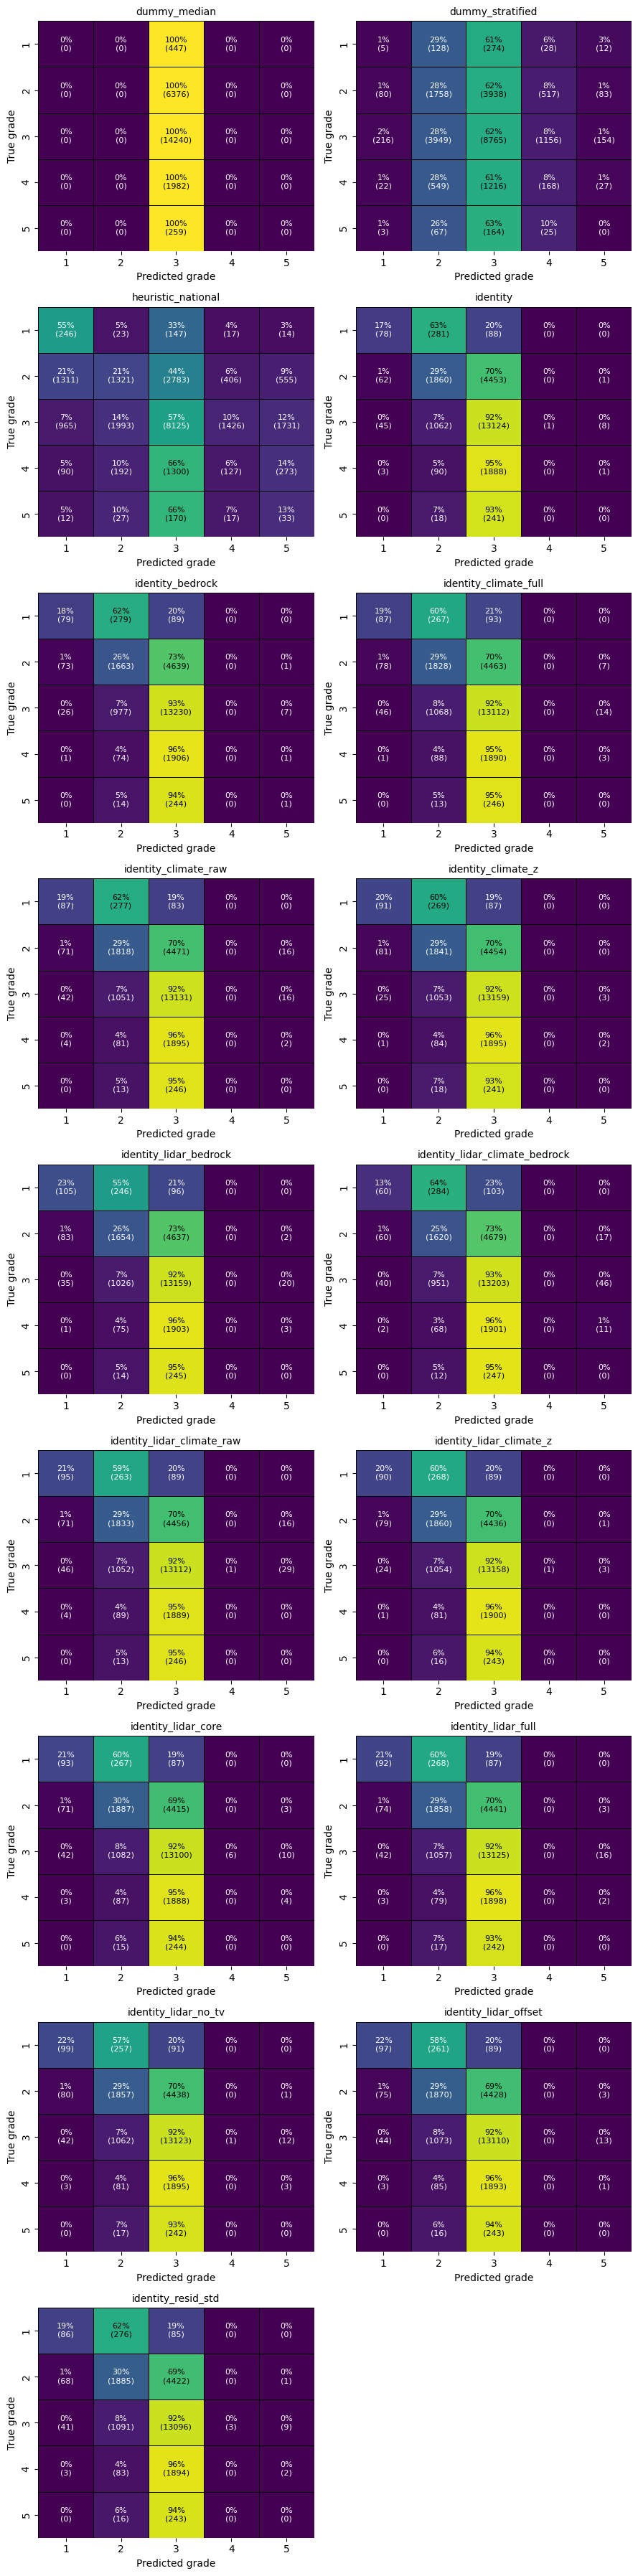

In [51]:
labels = cm_cells.get_column("label").to_list()
ncols = 2
nrows = -(-len(labels) // ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(9, 4 * nrows))
axes = axes.flatten()

for ax, label in zip(axes, labels):
    cm_wide = (
        cm.filter(pl.col("label") == label)
        .select("y_true", "y_pred_argmax", "n")
        .pivot(on="y_pred_argmax", index="y_true", values="n")
        .sort("y_true")
    )
    plot_confusion_matrix(cm_wide, title=label, ax=ax)

for ax in axes[len(labels):]:
    ax.axis("off")

fig.tight_layout()
plt.show()

In [61]:
sweep_cells = pl.concat(
    [
        cell_summary.filter(pl.col("composition") == feature_set)
        .sort("pr_auc_ge4", descending=True)
        .head(1)
        .select("cell_id", "model", "composition", "pr_auc_ge4", "qwk")
        for feature_set in ["identity_lidar", "identity"]
    ]
    + [
        cell_summary.filter(pl.col("composition").is_null()).select(
            "cell_id", "model", "composition", "pr_auc_ge4", "qwk"
        )
    ]
).with_columns(pl.coalesce(pl.col("composition"), pl.col("model")).alias("label"))

sweep_oof = pl.concat(
    [
        pl.read_parquet(oof_dir / f"{cell_id}.parquet").select(
            "cell_id",
            "fold_id",
            "asset_id",
            "y_true",
            pl.sum_horizontal("proba_4", "proba_5").alias("score"),
        )
        for cell_id in sweep_cells.get_column("cell_id")
    ]
).join(sweep_cells, on="cell_id", how="left", validate="m:1").with_columns(
    (pl.col("y_true") >= 4).alias("is_positive")
)

sweep_cells

cell_id,model,composition,pr_auc_ge4,qwk,label
str,str,str,f64,f64,str
"""da2ed2fa075c""","""hgb""","""identity""",0.178136,0.282329,"""identity"""
"""ba81faf7a77c""","""heuristic_national""",null,0.098838,0.185143,"""heuristic_national"""
"""0c7581b6dc44""","""dummy_stratified""",null,0.097513,-0.000851,"""dummy_stratified"""
"""4afa0082a12f""","""dummy_median""",null,0.096583,0.0,"""dummy_median"""


In [63]:
sweep_oof

cell_id,fold_id,asset_id,y_true,score,model,composition,pr_auc_ge4,qwk,label,is_positive
str,i8,i32,i8,f32,str,str,f64,f64,str,bool
"""da2ed2fa075c""",3,100006,3,0.05749,"""hgb""","""identity""",0.178136,0.282329,"""identity""",false
"""da2ed2fa075c""",3,100010,3,0.05749,"""hgb""","""identity""",0.178136,0.282329,"""identity""",false
"""da2ed2fa075c""",3,100015,4,0.0819,"""hgb""","""identity""",0.178136,0.282329,"""identity""",true
"""da2ed2fa075c""",3,100016,3,0.072683,"""hgb""","""identity""",0.178136,0.282329,"""identity""",false
"""da2ed2fa075c""",3,100017,3,0.071994,"""hgb""","""identity""",0.178136,0.282329,"""identity""",false
…,…,…,…,…,…,…,…,…,…,…
"""4afa0082a12f""",9,99960,3,0.0,"""dummy_median""",null,0.096583,0.0,"""dummy_median""",false
"""4afa0082a12f""",1,99963,3,0.0,"""dummy_median""",null,0.096583,0.0,"""dummy_median""",false
"""4afa0082a12f""",6,99966,3,0.0,"""dummy_median""",null,0.096583,0.0,"""dummy_median""",false


In [64]:
sweep_curve = (
    sweep_oof.group_by("cell_id", "label", "score")
    .agg(
        pl.len().alias("n_at_score"),
        pl.col("is_positive").sum().alias("n_pos_at_score"),
    )
    .sort("cell_id", "score", descending=[False, True])
    .with_columns(
        pl.col("n_at_score").cum_sum().over("cell_id").alias("n_flagged"),
        pl.col("n_pos_at_score").cum_sum().over("cell_id").alias("n_true_positive"),
        pl.col("n_at_score").sum().over("cell_id").alias("n_total"),
        pl.col("n_pos_at_score").sum().over("cell_id").alias("n_positive_total"),
    )
    .with_columns(
        (pl.col("n_true_positive") / pl.col("n_flagged")).alias("precision"),
        (pl.col("n_true_positive") / pl.col("n_positive_total")).alias("recall"),
        (pl.col("n_flagged") / pl.col("n_total")).alias("flagged_pct"),
        (pl.col("n_positive_total") / pl.col("n_total")).alias("base_rate"),
    )
    .with_columns((pl.col("precision") / pl.col("base_rate")).alias("lift"))
    .select(
        "label", "score", "n_flagged", "flagged_pct", "n_true_positive",
        "precision", "recall", "lift", "base_rate",
    )
)

# sweep_curve.filter(pl.col("label") == "identity_lidar").filter(
#     pl.col("n_flagged").is_between(500, 8000)
# ).gather_every(50)

sweep_curve.filter(
    pl.col("n_flagged").is_between(500, 8000)
).gather_every(50)

label,score,n_flagged,flagged_pct,n_true_positive,precision,recall,lift,base_rate
str,f32,u32,f64,u32,f64,f64,f64,f64
"""dummy_stratified""",1.0,2170,0.093117,220,0.101382,0.09817,1.054269,0.096164
"""identity""",0.224933,591,0.02536,149,0.252115,0.066488,2.621727,0.096164
"""identity""",0.216778,670,0.02875,171,0.255224,0.076305,2.654055,0.096164
"""identity""",0.207641,749,0.03214,199,0.265688,0.0888,2.762866,0.096164
"""identity""",0.200799,846,0.036303,218,0.257683,0.097278,2.679629,0.096164
…,…,…,…,…,…,…,…,…
"""identity""",0.107171,7710,0.330844,1233,0.159922,0.550201,1.663019,0.096164
"""identity""",0.10655,7780,0.333848,1238,0.159126,0.552432,1.65474,0.096164
"""identity""",0.105907,7850,0.336852,1243,0.158344,0.554663,1.646607,0.096164


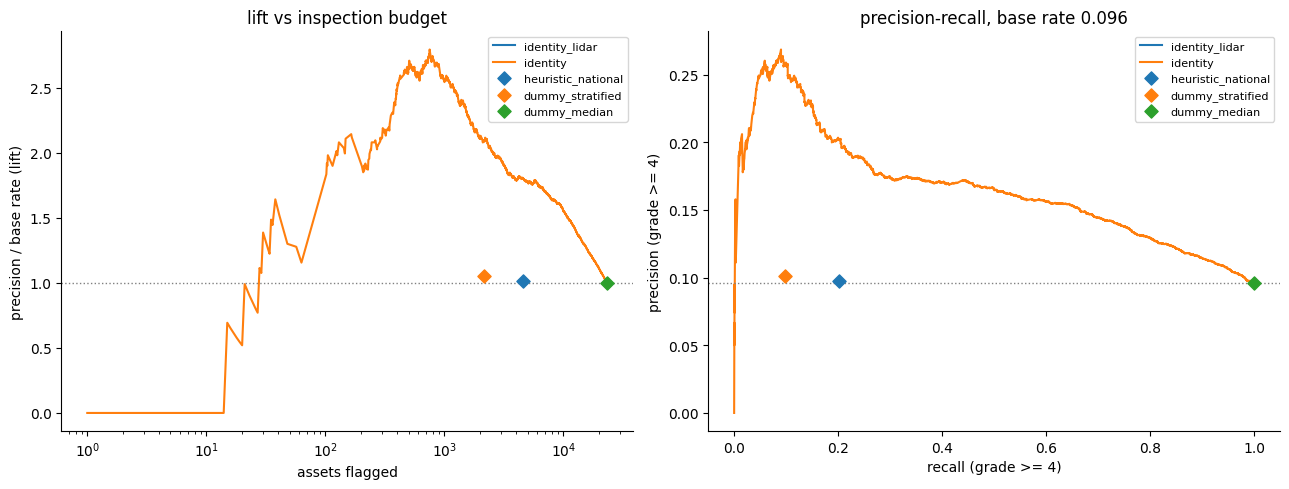

In [65]:
model_labels = ["identity_lidar", "identity"]
point_labels = ["heuristic_national", "dummy_stratified", "dummy_median"]
base_rate = sweep_curve.get_column("base_rate").max()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for label in model_labels:
    curve = sweep_curve.filter(pl.col("label") == label).sort("n_flagged")
    axes[0].plot(curve["n_flagged"], curve["lift"], label=label, linewidth=1.5)
    axes[1].plot(curve["recall"], curve["precision"], label=label, linewidth=1.5)

for label in point_labels:
    point = (
        sweep_curve.filter((pl.col("label") == label) & (pl.col("n_flagged") > 0))
        .sort("lift", descending=True)
        .head(1)
    )
    axes[0].scatter(point["n_flagged"], point["lift"], marker="D", s=45, zorder=5, label=label)
    axes[1].scatter(point["recall"], point["precision"], marker="D", s=45, zorder=5, label=label)

axes[0].axhline(1.0, color="grey", linestyle=":", linewidth=1)
axes[0].set_xscale("log")
axes[0].set_xlabel("assets flagged")
axes[0].set_ylabel("precision / base rate (lift)")
axes[0].set_title("lift vs inspection budget")

axes[1].axhline(base_rate, color="grey", linestyle=":", linewidth=1)
axes[1].set_xlabel("recall (grade >= 4)")
axes[1].set_ylabel("precision (grade >= 4)")
axes[1].set_title(f"precision-recall, base rate {base_rate:.3f}")

for ax in axes:
    ax.legend(fontsize=8)
    ax.spines[["top", "right"]].set_visible(False)

fig.tight_layout()
plt.show()

In [76]:
all_feature_sets = cell_summary.get_column("composition").unique().drop_nulls().to_list()

sweep_cells = pl.concat(
    [
        cell_summary.filter(pl.col("composition").eq(composition))
        .sort("pr_auc_ge4", descending=True)
        .head(1)
        .select("cell_id", "model", "composition", "pr_auc_ge4", "qwk")
        for composition in all_feature_sets
    ]
    + [
        cell_summary.filter(pl.col("composition").is_null()).select(
            "cell_id", "model", "composition", "pr_auc_ge4", "qwk"
        )
    ]
).with_columns(pl.coalesce(pl.col("composition"), pl.col("model")).alias("label"))

sweep_oof = pl.concat(
    [
        pl.read_parquet(oof_dir / f"{cell_id}.parquet").select(
            "cell_id",
            "fold_id",
            "asset_id",
            "y_true",
            pl.sum_horizontal("proba_4", "proba_5").alias("score"),
        )
        for cell_id in sweep_cells.get_column("cell_id")
    ]
).join(sweep_cells, on="cell_id", how="left", validate="m:1").with_columns(
    (pl.col("y_true") >= 4).alias("is_positive")
)

sweep_curve = (
    sweep_oof.group_by("cell_id", "label", "score")
    .agg(
        pl.len().alias("n_at_score"),
        pl.col("is_positive").sum().alias("n_pos_at_score"),
    )
    .sort("cell_id", "score", descending=[False, True])
    .with_columns(
        pl.col("n_at_score").cum_sum().over("cell_id").alias("n_flagged"),
        pl.col("n_pos_at_score").cum_sum().over("cell_id").alias("n_true_positive"),
        pl.col("n_at_score").sum().over("cell_id").alias("n_total"),
        pl.col("n_pos_at_score").sum().over("cell_id").alias("n_positive_total"),
    )
    .with_columns(
        (pl.col("n_true_positive") / pl.col("n_flagged")).alias("precision"),
        (pl.col("n_true_positive") / pl.col("n_positive_total")).alias("recall"),
        (pl.col("n_flagged") / pl.col("n_total")).alias("flagged_pct"),
        (pl.col("n_positive_total") / pl.col("n_total")).alias("base_rate"),
    )
    .with_columns((pl.col("precision") / pl.col("base_rate")).alias("lift"))
    .select(
        "label", "score", "n_flagged", "flagged_pct", "n_true_positive",
        "precision", "recall", "lift", "base_rate",
    )
)

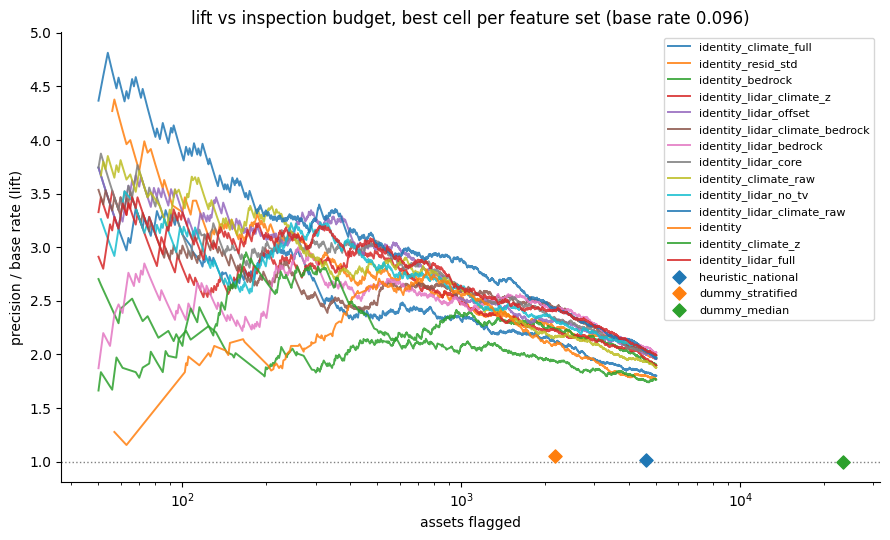

In [77]:
point_labels = ["heuristic_national", "dummy_stratified", "dummy_median"]
base_rate = sweep_curve.get_column("base_rate").max()

fig, ax = plt.subplots(figsize=(9, 5.5))

for feature_set in all_feature_sets:
    curve = (
        sweep_curve.filter(pl.col("label") == feature_set)
        .filter(pl.col("n_flagged").is_between(50, 5000))
        .sort("n_flagged")
    )
    ax.plot(
        curve["n_flagged"],
        curve["lift"],
        label=feature_set,
        linewidth=1.4,
        alpha=0.85,
    )

for label in point_labels:
    point = (
        sweep_curve.filter((pl.col("label") == label) & (pl.col("n_flagged") > 0))
        .sort("lift", descending=True)
        .head(1)
    )
    ax.scatter(point["n_flagged"], point["lift"], marker="D", s=45, zorder=5, label=label)

ax.axhline(1.0, color="grey", linestyle=":", linewidth=1)
ax.set_xscale("log")
ax.set_xlabel("assets flagged")
ax.set_ylabel("precision / base rate (lift)")
ax.set_title(f"lift vs inspection budget, best cell per feature set (base rate {base_rate:.3f})")
ax.legend(fontsize=8)
ax.spines[["top", "right"]].set_visible(False)

fig.tight_layout()
plt.show()

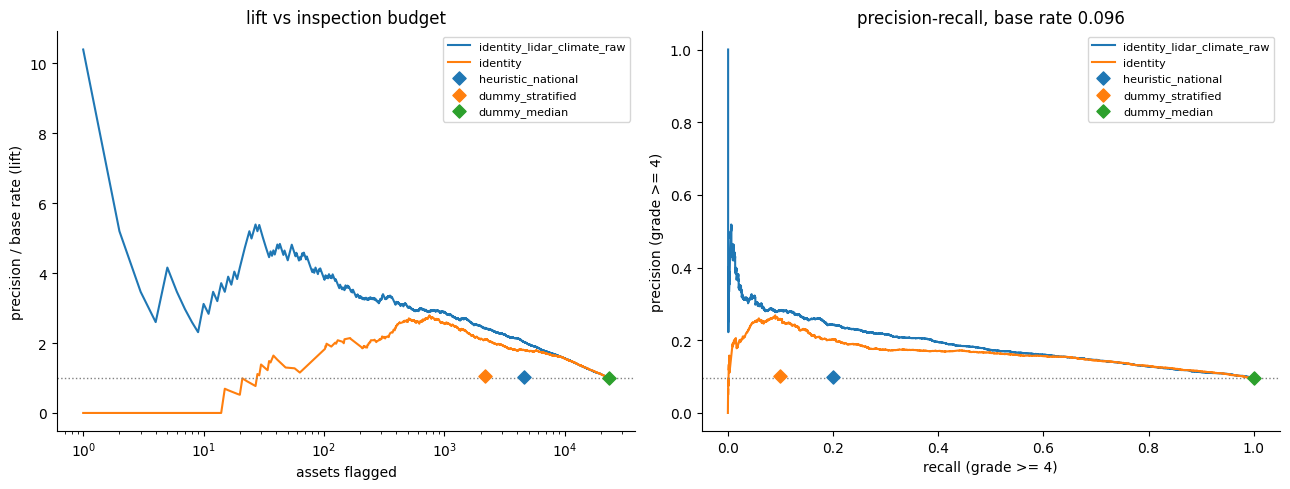

In [70]:
model_labels = ["identity_lidar_climate_raw", "identity"]
point_labels = ["heuristic_national", "dummy_stratified", "dummy_median"]
base_rate = sweep_curve.get_column("base_rate").max()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for label in model_labels:
    curve = sweep_curve.filter(pl.col("label") == label).sort("n_flagged")
    axes[0].plot(curve["n_flagged"], curve["lift"], label=label, linewidth=1.5)
    axes[1].plot(curve["recall"], curve["precision"], label=label, linewidth=1.5)

for label in point_labels:
    point = (
        sweep_curve.filter((pl.col("label") == label) & (pl.col("n_flagged") > 0))
        .sort("lift", descending=True)
        .head(1)
    )
    axes[0].scatter(point["n_flagged"], point["lift"], marker="D", s=45, zorder=5, label=label)
    axes[1].scatter(point["recall"], point["precision"], marker="D", s=45, zorder=5, label=label)

axes[0].axhline(1.0, color="grey", linestyle=":", linewidth=1)
axes[0].set_xscale("log")
axes[0].set_xlabel("assets flagged")
axes[0].set_ylabel("precision / base rate (lift)")
axes[0].set_title("lift vs inspection budget")

axes[1].axhline(base_rate, color="grey", linestyle=":", linewidth=1)
axes[1].set_xlabel("recall (grade >= 4)")
axes[1].set_ylabel("precision (grade >= 4)")
axes[1].set_title(f"precision-recall, base rate {base_rate:.3f}")

for ax in axes:
    ax.legend(fontsize=8)
    ax.spines[["top", "right"]].set_visible(False)

fig.tight_layout()
plt.show()

In [71]:
budget = 200
matrix_labels = ["identity", "identity_lidar_climate_raw", "heuristic_national"]

binary_rows = []
for label in matrix_labels:
    ranked = sweep_oof.filter(pl.col("label") == label).sort("score", descending=True)
    flagged = (
        ranked.with_row_index("rank")
        .with_columns((pl.col("rank") < budget).alias("flagged"))
        .group_by("flagged", "is_positive")
        .agg(pl.len().alias("n"))
    )
    binary_rows.append(flagged.with_columns(pl.lit(label).alias("label")))

binary_matrix = (
    pl.concat(binary_rows)
    .pivot(on="is_positive", index=["label", "flagged"], values="n")
    .rename({"true": "actually_ge4", "false": "actually_below4"})
    .sort("label", "flagged", descending=[False, True])
)

binary_matrix

label,flagged,actually_ge4,actually_below4
str,bool,u32,u32
"""heuristic_national""",true,24,176
"""heuristic_national""",false,2217,20887
"""identity""",true,36,164
"""identity""",false,2205,20899
"""identity_lidar_climate_raw""",true,64,136
"""identity_lidar_climate_raw""",false,2177,20927


In [72]:
binary_summary = (
    binary_matrix.group_by("label")
    .agg(
        pl.col("actually_ge4").filter(pl.col("flagged")).first().alias("true_positive"),
        pl.col("actually_below4").filter(pl.col("flagged")).first().alias("false_positive"),
        pl.col("actually_ge4").filter(~pl.col("flagged")).first().alias("false_negative"),
        pl.col("actually_below4").filter(~pl.col("flagged")).first().alias("true_negative"),
    )
    .with_columns(
        (pl.col("true_positive") / (pl.col("true_positive") + pl.col("false_positive"))).alias("precision"),
        (pl.col("true_positive") / (pl.col("true_positive") + pl.col("false_negative"))).alias("recall"),
    )
    .with_columns((pl.col("precision") / 0.096164).alias("lift"))
    .sort("lift", descending=True)
)

binary_summary

label,true_positive,false_positive,false_negative,true_negative,precision,recall,lift
str,u32,u32,u32,u32,f64,f64,f64
"""identity_lidar_climate_raw""",64,136,2177,20927,0.32,0.028559,3.327649
"""identity""",36,164,2205,20899,0.18,0.016064,1.871802
"""heuristic_national""",24,176,2217,20887,0.12,0.01071,1.247868


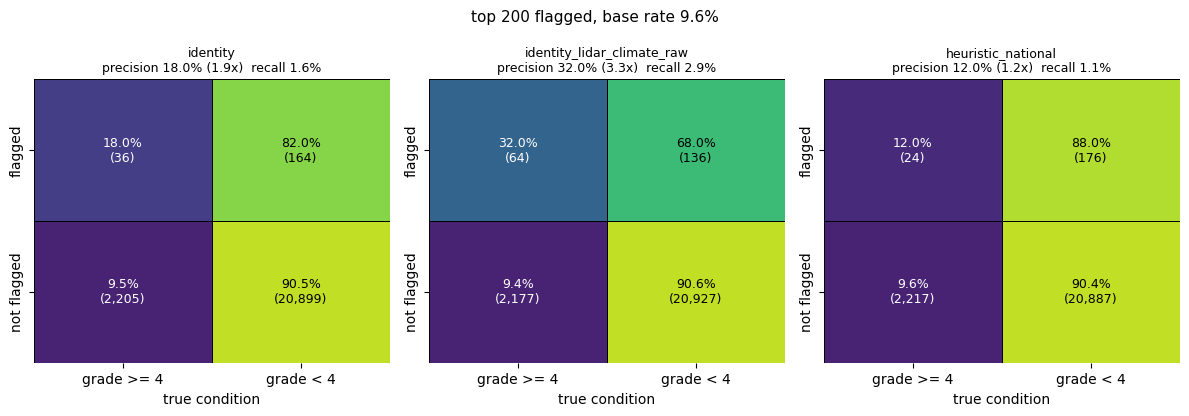

In [73]:
base_rate = 0.096164

fig, axes = plt.subplots(1, len(matrix_labels), figsize=(4 * len(matrix_labels), 4.2))

for ax, label in zip(axes, matrix_labels):
    ranked = sweep_oof.filter(pl.col("label") == label).sort("score", descending=True)
    positives = ranked.get_column("is_positive").to_numpy()

    true_positive = int(positives[:budget].sum())
    false_positive = budget - true_positive
    false_negative = int(positives[budget:].sum())
    true_negative = len(positives) - budget - false_negative

    counts = np.array([[true_positive, false_positive], [false_negative, true_negative]])
    shares = counts / counts.sum(axis=1, keepdims=True)

    sns.heatmap(
        shares,
        cmap="viridis",
        vmin=0,
        vmax=1,
        cbar=False,
        xticklabels=["grade >= 4", "grade < 4"],
        yticklabels=["flagged", "not flagged"],
        ax=ax,
        linewidths=0.5,
        linecolor="black",
    )

    for i in range(2):
        for j in range(2):
            ax.text(
                j + 0.5,
                i + 0.5,
                f"{shares[i, j]:.1%}\n({counts[i, j]:,})",
                ha="center",
                va="center",
                fontsize=9,
                color="white" if shares[i, j] < 0.6 else "black",
            )

    precision = true_positive / budget
    recall = true_positive / (true_positive + false_negative)
    ax.set_title(
        f"{label}\nprecision {precision:.1%} ({precision / base_rate:.1f}x)  recall {recall:.1%}",
        fontsize=9,
    )
    ax.set_xlabel("true condition")
    ax.set_ylabel("")

fig.suptitle(f"top {budget} flagged, base rate {base_rate:.1%}", fontsize=11)
fig.tight_layout()
plt.show()

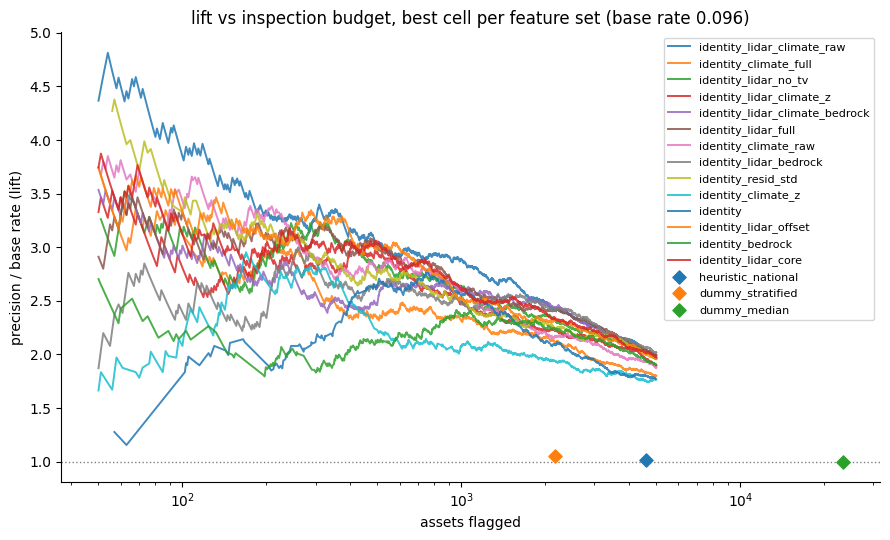

In [78]:
all_feature_sets = cell_summary_nd.get_column("composition").unique().drop_nulls().to_list()

sweep_cells = pl.concat(
    [
        cell_summary_nd.filter(pl.col("composition").eq(composition))
        .sort("pr_auc_ge4", descending=True)
        .head(1)
        .select("cell_id", "model", "composition", "pr_auc_ge4", "qwk")
        for composition in all_feature_sets
    ]
    + [
        cell_summary_nd.filter(pl.col("composition").is_null()).select(
            "cell_id", "model", "composition", "pr_auc_ge4", "qwk"
        )
    ]
).with_columns(pl.coalesce(pl.col("composition"), pl.col("model")).alias("label"))

sweep_oof = pl.concat(
    [
        pl.read_parquet(oof_dir / f"{cell_id}.parquet").select(
            "cell_id",
            "fold_id",
            "asset_id",
            "y_true",
            pl.sum_horizontal("proba_4", "proba_5").alias("score"),
        )
        for cell_id in sweep_cells.get_column("cell_id")
    ]
).join(sweep_cells, on="cell_id", how="left", validate="m:1").with_columns(
    (pl.col("y_true") >= 4).alias("is_positive")
)

sweep_curve = (
    sweep_oof.group_by("cell_id", "label", "score")
    .agg(
        pl.len().alias("n_at_score"),
        pl.col("is_positive").sum().alias("n_pos_at_score"),
    )
    .sort("cell_id", "score", descending=[False, True])
    .with_columns(
        pl.col("n_at_score").cum_sum().over("cell_id").alias("n_flagged"),
        pl.col("n_pos_at_score").cum_sum().over("cell_id").alias("n_true_positive"),
        pl.col("n_at_score").sum().over("cell_id").alias("n_total"),
        pl.col("n_pos_at_score").sum().over("cell_id").alias("n_positive_total"),
    )
    .with_columns(
        (pl.col("n_true_positive") / pl.col("n_flagged")).alias("precision"),
        (pl.col("n_true_positive") / pl.col("n_positive_total")).alias("recall"),
        (pl.col("n_flagged") / pl.col("n_total")).alias("flagged_pct"),
        (pl.col("n_positive_total") / pl.col("n_total")).alias("base_rate"),
    )
    .with_columns((pl.col("precision") / pl.col("base_rate")).alias("lift"))
    .select(
        "label", "score", "n_flagged", "flagged_pct", "n_true_positive",
        "precision", "recall", "lift", "base_rate",
    )
)


point_labels = ["heuristic_national", "dummy_stratified", "dummy_median"]
base_rate = sweep_curve.get_column("base_rate").max()

fig, ax = plt.subplots(figsize=(9, 5.5))

for feature_set in all_feature_sets:
    curve = (
        sweep_curve.filter(pl.col("label") == feature_set)
        .filter(pl.col("n_flagged").is_between(50, 5000))
        .sort("n_flagged")
    )
    ax.plot(
        curve["n_flagged"],
        curve["lift"],
        label=feature_set,
        linewidth=1.4,
        alpha=0.85,
    )

for label in point_labels:
    point = (
        sweep_curve.filter((pl.col("label") == label) & (pl.col("n_flagged") > 0))
        .sort("lift", descending=True)
        .head(1)
    )
    ax.scatter(point["n_flagged"], point["lift"], marker="D", s=45, zorder=5, label=label)

ax.axhline(1.0, color="grey", linestyle=":", linewidth=1)
ax.set_xscale("log")
ax.set_xlabel("assets flagged")
ax.set_ylabel("precision / base rate (lift)")
ax.set_title(f"lift vs inspection budget, best cell per feature set (base rate {base_rate:.3f})")
ax.legend(fontsize=8)
ax.spines[["top", "right"]].set_visible(False)

fig.tight_layout()
plt.show()

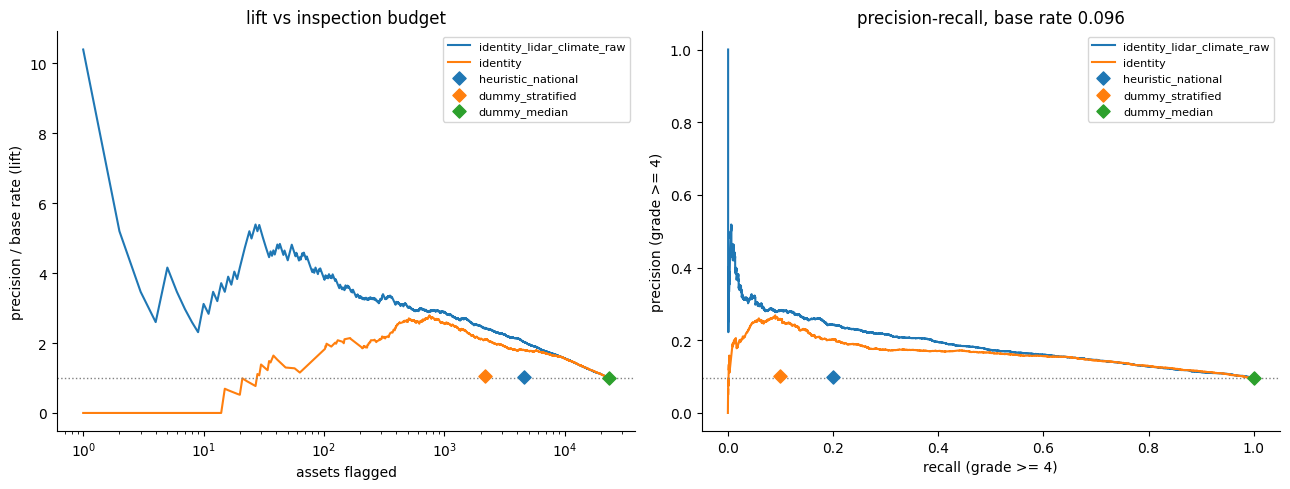

In [79]:
model_labels = ["identity_lidar_climate_raw", "identity"]
point_labels = ["heuristic_national", "dummy_stratified", "dummy_median"]
base_rate = sweep_curve.get_column("base_rate").max()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for label in model_labels:
    curve = sweep_curve.filter(pl.col("label") == label).sort("n_flagged")
    axes[0].plot(curve["n_flagged"], curve["lift"], label=label, linewidth=1.5)
    axes[1].plot(curve["recall"], curve["precision"], label=label, linewidth=1.5)

for label in point_labels:
    point = (
        sweep_curve.filter((pl.col("label") == label) & (pl.col("n_flagged") > 0))
        .sort("lift", descending=True)
        .head(1)
    )
    axes[0].scatter(point["n_flagged"], point["lift"], marker="D", s=45, zorder=5, label=label)
    axes[1].scatter(point["recall"], point["precision"], marker="D", s=45, zorder=5, label=label)

axes[0].axhline(1.0, color="grey", linestyle=":", linewidth=1)
axes[0].set_xscale("log")
axes[0].set_xlabel("assets flagged")
axes[0].set_ylabel("precision / base rate (lift)")
axes[0].set_title("lift vs inspection budget")

axes[1].axhline(base_rate, color="grey", linestyle=":", linewidth=1)
axes[1].set_xlabel("recall (grade >= 4)")
axes[1].set_ylabel("precision (grade >= 4)")
axes[1].set_title(f"precision-recall, base rate {base_rate:.3f}")

for ax in axes:
    ax.legend(fontsize=8)
    ax.spines[["top", "right"]].set_visible(False)

fig.tight_layout()
plt.show()

In [80]:
budget = 200
matrix_labels = ["identity", "identity_lidar_climate_raw", "heuristic_national"]

binary_rows = []
for label in matrix_labels:
    ranked = sweep_oof.filter(pl.col("label") == label).sort("score", descending=True)
    flagged = (
        ranked.with_row_index("rank")
        .with_columns((pl.col("rank") < budget).alias("flagged"))
        .group_by("flagged", "is_positive")
        .agg(pl.len().alias("n"))
    )
    binary_rows.append(flagged.with_columns(pl.lit(label).alias("label")))

binary_matrix = (
    pl.concat(binary_rows)
    .pivot(on="is_positive", index=["label", "flagged"], values="n")
    .rename({"true": "actually_ge4", "false": "actually_below4"})
    .sort("label", "flagged", descending=[False, True])
)

binary_summary = (
    binary_matrix.group_by("label")
    .agg(
        pl.col("actually_ge4").filter(pl.col("flagged")).first().alias("true_positive"),
        pl.col("actually_below4").filter(pl.col("flagged")).first().alias("false_positive"),
        pl.col("actually_ge4").filter(~pl.col("flagged")).first().alias("false_negative"),
        pl.col("actually_below4").filter(~pl.col("flagged")).first().alias("true_negative"),
    )
    .with_columns(
        (pl.col("true_positive") / (pl.col("true_positive") + pl.col("false_positive"))).alias("precision"),
        (pl.col("true_positive") / (pl.col("true_positive") + pl.col("false_negative"))).alias("recall"),
    )
    .with_columns((pl.col("precision") / 0.096164).alias("lift"))
    .sort("lift", descending=True)
)

binary_summary

label,true_positive,false_positive,false_negative,true_negative,precision,recall,lift
str,u32,u32,u32,u32,f64,f64,f64
"""identity_lidar_climate_raw""",64,136,2177,20927,0.32,0.028559,3.327649
"""identity""",36,164,2205,20899,0.18,0.016064,1.871802
"""heuristic_national""",24,176,2217,20887,0.12,0.01071,1.247868


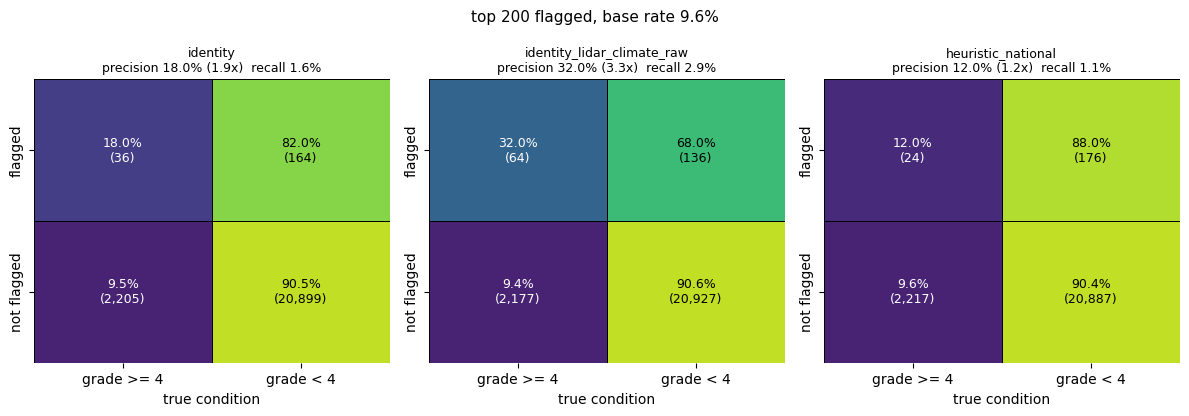

In [81]:
base_rate = 0.096164

fig, axes = plt.subplots(1, len(matrix_labels), figsize=(4 * len(matrix_labels), 4.2))

for ax, label in zip(axes, matrix_labels):
    ranked = sweep_oof.filter(pl.col("label") == label).sort("score", descending=True)
    positives = ranked.get_column("is_positive").to_numpy()

    true_positive = int(positives[:budget].sum())
    false_positive = budget - true_positive
    false_negative = int(positives[budget:].sum())
    true_negative = len(positives) - budget - false_negative

    counts = np.array([[true_positive, false_positive], [false_negative, true_negative]])
    shares = counts / counts.sum(axis=1, keepdims=True)

    sns.heatmap(
        shares,
        cmap="viridis",
        vmin=0,
        vmax=1,
        cbar=False,
        xticklabels=["grade >= 4", "grade < 4"],
        yticklabels=["flagged", "not flagged"],
        ax=ax,
        linewidths=0.5,
        linecolor="black",
    )

    for i in range(2):
        for j in range(2):
            ax.text(
                j + 0.5,
                i + 0.5,
                f"{shares[i, j]:.1%}\n({counts[i, j]:,})",
                ha="center",
                va="center",
                fontsize=9,
                color="white" if shares[i, j] < 0.6 else "black",
            )

    precision = true_positive / budget
    recall = true_positive / (true_positive + false_negative)
    ax.set_title(
        f"{label}\nprecision {precision:.1%} ({precision / base_rate:.1f}x)  recall {recall:.1%}",
        fontsize=9,
    )
    ax.set_xlabel("true condition")
    ax.set_ylabel("")

fig.suptitle(f"top {budget} flagged, base rate {base_rate:.1%}", fontsize=11)
fig.tight_layout()
plt.show()

using the configs with the colapsed cells filtered out doesn't make a huge difference, expected since pr auc still ranked. 
